In [1]:
# Mental Health & Workplace Trends Analysis
# Nigel T. Chihuri | Data Analytics Portfolio — Project 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_excel(r'C:\Users\nigel\Documents\Data Analytics Journey\Mental Health Workplace Analysis\OSMI_Survey_Data.xlsx')

# First look
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\nigel\\Documents\\Data Analytics Journey\\Mental Health Workplace Analysis\\OSMI_Survey_Data.xlsx'

In [3]:
import os

folder = r'C:\Users\nigel\Documents\Data Analytics Journey\Mental Health Workplace Analysis'

print("Files in folder:")
for file in os.listdir(folder):
    print(file)

Files in folder:
.ipynb_checkpoints
mental_health_analysis.ipynb
OSMI-Data-Layout.pdf
OSMI_Survey_Data.csv


In [4]:
# Load the dataset
df = pd.read_csv(r'C:\Users\nigel\Documents\Data Analytics Journey\Mental Health Workplace Analysis\OSMI_Survey_Data.csv')

# First look
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (60186, 28)

Column Names:
['index', 'ResponseID', 'Are you selfemployed', 'How many employees does your company or organization have', 'Is your employer primarily a tech companyorganization', 'Is your primary role within your company related to techIT', 'Do you have previous employers', 'Do you have a family history of mental illness', 'Have you had a mental health disorder in the past', 'Do you currently have a mental health disorder', 'If yes, what conditions have you been diagnosed with', 'If maybe, what conditions do you believe you have', 'Have you been diagnosed with a mental health condition by a medical professional', 'If so, what conditions were you diagnosed with', 'Have you ever sought treatment for a mental health issue from a mental health professional', 'What is your age', 'What is your gender ', 'Age Group', 'What country do you live in', 'What US state or territory do you live in', 'What country do you work in', 'What US state or territory do you work in', 'Whic

,index,ResponseID,Are you selfemployed,How many employees does your company or organization have,Is your employer primarily a tech companyorganization,Is your primary role within your company related to techIT,Do you have previous employers,Do you have a family history of mental illness,Have you had a mental health disorder in the past,Do you currently have a mental health disorder,"If yes, what conditions have you been diagnosed with","If maybe, what conditions do you believe you have",Have you been diagnosed with a mental health condition by a medical professional,"If so, what conditions were you diagnosed with",Have you ever sought treatment for a mental health issue from a mental health professional,What is your age,What is your gender,Age Group,What country do you live in,What US state or territory do you live in,What country do you work in,What US state or territory do you work in,Which of the following best describes your work position,Do you work remotely,Question Group,Question about speaking openly about mental health vs physical health,Question,Response
0,0,r00000,False,26-100,True,NaN,True,No,Yes,No,NaN,NaN,True,"Anxiety Disorder (Generalized, Social, Phobia,...",False,39.0,Male,36-40,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes,Resources for employees with mental health dis...,No,Does your employer provide mental health benef...,Not eligible for coverage / N/A
1,1,r00000,False,26-100,True,NaN,True,No,Yes,No,NaN,NaN,True,"Anxiety Disorder (Generalized, Social, Phobia,...",False,39.0,Male,36-40,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes,Resources for employees with mental health dis...,No,Do you know the options for mental health care...,NaN
2,2,r00000,False,26-100,True,NaN,True,No,Yes,No,NaN,NaN,True,"Anxiety Disorder (Generalized, Social, Phobia,...",False,39.0,Male,36-40,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes,Safe and supportive workplce for those with me...,No,Has your employer ever formally discussed ment...,No
3,3,r00000,False,26-100,True,NaN,True,No,Yes,No,NaN,NaN,True,"Anxiety Disorder (Generalized, Social, Phobia,...",False,39.0,Male,36-40,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes,Resources for employees with mental health dis...,No,Does your employer offer resources to learn mo...,No
4,4,r00000,False,26-100,True,NaN,True,No,Yes,No,NaN,NaN,True,"Anxiety Disorder (Generalized, Social, Phobia,...",False,39.0,Male,36-40,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes,Resources for employees with mental health dis...,No,Is your anonymity protected if you choose to t...,I don't know


In [5]:
# Explore the data
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Shape: (60186, 28)

Data Types:
index                                                                                           int64
ResponseID                                                                                     object
Are you selfemployed                                                                             bool
How many employees does your company or organization have                                      object
Is your employer primarily a tech companyorganization                                          object
Is your primary role within your company related to techIT                                     object
Do you have previous employers                                                                   bool
Do you have a family history of mental illness                                                 object
Have you had a mental health disorder in the past                                              object
Do you currently have a mental health disorder    

In [6]:
# ============================================================
# DATA CLEANING & EXPLORATORY DATA ANALYSIS
# Project 3: Mental Health & Workplace Trends Analysis
# Analyst: Nigel T. Chihuri
# ============================================================

# ── INITIAL INSPECTION ──────────────────────────────────
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
print("Column Names & Dtypes:")
print(df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

DATASET OVERVIEW
Shape: 60,186 rows × 28 columns

Column Names & Dtypes:
index                                                                                           int64
ResponseID                                                                                     object
Are you selfemployed                                                                             bool
How many employees does your company or organization have                                      object
Is your employer primarily a tech companyorganization                                          object
Is your primary role within your company related to techIT                                     object
Do you have previous employers                                                                   bool
Do you have a family history of mental illness                                                 object
Have you had a mental health disorder in the past                                              object
Do you cu

,index,ResponseID,Are you selfemployed,How many employees does your company or organization have,Is your employer primarily a tech companyorganization,Is your primary role within your company related to techIT,Do you have previous employers,Do you have a family history of mental illness,Have you had a mental health disorder in the past,Do you currently have a mental health disorder,"If yes, what conditions have you been diagnosed with","If maybe, what conditions do you believe you have",Have you been diagnosed with a mental health condition by a medical professional,"If so, what conditions were you diagnosed with",Have you ever sought treatment for a mental health issue from a mental health professional,What is your age,What is your gender,Age Group,What country do you live in,What US state or territory do you live in,What country do you work in,What US state or territory do you work in,Which of the following best describes your work position,Do you work remotely,Question Group,Question about speaking openly about mental health vs physical health,Question,Response
0,0,r00000,False,26-100,True,NaN,True,No,Yes,No,NaN,NaN,True,"Anxiety Disorder (Generalized, Social, Phobia,...",False,39.0,Male,36-40,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes,Resources for employees with mental health dis...,No,Does your employer provide mental health benef...,Not eligible for coverage / N/A
1,1,r00000,False,26-100,True,NaN,True,No,Yes,No,NaN,NaN,True,"Anxiety Disorder (Generalized, Social, Phobia,...",False,39.0,Male,36-40,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes,Resources for employees with mental health dis...,No,Do you know the options for mental health care...,NaN
2,2,r00000,False,26-100,True,NaN,True,No,Yes,No,NaN,NaN,True,"Anxiety Disorder (Generalized, Social, Phobia,...",False,39.0,Male,36-40,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes,Safe and supportive workplce for those with me...,No,Has your employer ever formally discussed ment...,No


In [7]:
# ── MISSING VALUE AUDIT ─────────────────────────────────
print("=" * 60)
print("MISSING VALUE AUDIT")
print("=" * 60)

missing = (df.isnull().sum()
             .reset_index()
             .rename(columns={0: 'missing_count', 'index': 'column'}))
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(missing.to_string(index=False))
print(f"\nColumns with NO missing values: {df.shape[1] - len(missing)}")

MISSING VALUE AUDIT
                                                    column  missing_count  missing_pct
Is your primary role within your company related to techIT          49140        81.65
         If maybe, what conditions do you believe you have          46662        77.53
      If yes, what conditions have you been diagnosed with          36330        60.36
            If so, what conditions were you diagnosed with          30324        50.38
                 What US state or territory do you live in          24906        41.38
                 What US state or territory do you work in          24444        40.61
                                                  Response          16340        27.15
 How many employees does your company or organization have          12054        20.03
     Is your employer primarily a tech companyorganization          12054        20.03
                                            Question Group           8598        14.29
                       

In [8]:
# ── COLUMN STANDARDISATION ──────────────────────────────
# Standardise column names: lowercase, replace spaces with underscores
df.columns = (df.columns
                .str.strip()
                .str.lower()
                .str.replace(' ', '_', regex=False)
                .str.replace(r'[^\w]', '_', regex=True))

print("Standardised column names:")
print(df.columns.tolist())

Standardised column names:
['index', 'responseid', 'are_you_selfemployed', 'how_many_employees_does_your_company_or_organization_have', 'is_your_employer_primarily_a_tech_companyorganization', 'is_your_primary_role_within_your_company_related_to_techit', 'do_you_have_previous_employers', 'do_you_have_a_family_history_of_mental_illness', 'have_you_had_a_mental_health_disorder_in_the_past', 'do_you_currently_have_a_mental_health_disorder', 'if_yes__what_conditions_have_you_been_diagnosed_with', 'if_maybe__what_conditions_do_you_believe_you_have', 'have_you_been_diagnosed_with_a_mental_health_condition_by_a_medical_professional', 'if_so__what_conditions_were_you_diagnosed_with', 'have_you_ever_sought_treatment_for_a_mental_health_issue_from_a_mental_health_professional', 'what_is_your_age', 'what_is_your_gender', 'age_group', 'what_country_do_you_live_in', 'what_us_state_or_territory_do_you_live_in', 'what_country_do_you_work_in', 'what_us_state_or_territory_do_you_work_in', 'which_of_the

In [9]:
# ── CLEAN KEY COLUMNS ───────────────────────────────────
# --- Age ---
print("Age — before cleaning:")
print(df['age'].describe())

# Remove biologically implausible ages
df = df[(df['age'] >= 16) & (df['age'] <= 75)]
print("\nAge — after cleaning:")
print(df['age'].describe())

# --- Gender ---
print("\nGender — raw value counts (top 20):")
print(df['gender'].value_counts().head(20))

# Normalise gender to 3 categories
gender_map = {
    'male': 'Male', 'man': 'Male', 'm': 'Male', 'male ': 'Male',
    'cis male': 'Male', 'cis man': 'Male', 'male (cis)': 'Male',
    'female': 'Female', 'woman': 'Female', 'f': 'Female', 'female ': 'Female',
    'cis female': 'Female', 'cis woman': 'Female', 'female (cis)': 'Female',
    'femake': 'Female', 'femail': 'Female',
}

df['gender_clean'] = (df['gender']
                        .str.strip()
                        .str.lower()
                        .map(gender_map)
                        .fillna('Non-binary / Other'))

print("\nGender — after cleaning:")
print(df['gender_clean'].value_counts())

Age — before cleaning:


KeyError: 'age'

In [10]:
# DIAGNOSTIC — run this as a standalone cell
print(df.columns.tolist())

['index', 'responseid', 'are_you_selfemployed', 'how_many_employees_does_your_company_or_organization_have', 'is_your_employer_primarily_a_tech_companyorganization', 'is_your_primary_role_within_your_company_related_to_techit', 'do_you_have_previous_employers', 'do_you_have_a_family_history_of_mental_illness', 'have_you_had_a_mental_health_disorder_in_the_past', 'do_you_currently_have_a_mental_health_disorder', 'if_yes__what_conditions_have_you_been_diagnosed_with', 'if_maybe__what_conditions_do_you_believe_you_have', 'have_you_been_diagnosed_with_a_mental_health_condition_by_a_medical_professional', 'if_so__what_conditions_were_you_diagnosed_with', 'have_you_ever_sought_treatment_for_a_mental_health_issue_from_a_mental_health_professional', 'what_is_your_age', 'what_is_your_gender', 'age_group', 'what_country_do_you_live_in', 'what_us_state_or_territory_do_you_live_in', 'what_country_do_you_work_in', 'what_us_state_or_territory_do_you_work_in', 'which_of_the_following_best_describes_y

In [11]:
# ── CLEAN KEY COLUMNS ───────────────────────────────────

# --- Age ---
age_col = 'what_is_your_age'
print(f"Age — before cleaning:")
print(df[age_col].describe())

df[age_col] = pd.to_numeric(df[age_col], errors='coerce')
df = df[(df[age_col] >= 16) & (df[age_col] <= 75)]
print(f"\nAge — after cleaning:")
print(df[age_col].describe())

# --- Gender ---
gender_col = 'what_is_your_gender'
print(f"\nGender — raw value counts (top 20):")
print(df[gender_col].value_counts().head(20))

gender_map = {
    'male': 'Male', 'man': 'Male', 'm': 'Male', 'male ': 'Male',
    'cis male': 'Male', 'cis man': 'Male', 'male (cis)': 'Male',
    'maile': 'Male', 'mal': 'Male', 'msle': 'Male', 'make': 'Male',
    'female': 'Female', 'woman': 'Female', 'f': 'Female', 'female ': 'Female',
    'cis female': 'Female', 'cis woman': 'Female', 'female (cis)': 'Female',
    'femake': 'Female', 'femail': 'Female', 'woman ': 'Female',
}

df['gender_clean'] = (df[gender_col]
                        .str.strip()
                        .str.lower()
                        .map(gender_map)
                        .fillna('Non-binary / Other'))

print(f"\nGender — after cleaning:")
print(df['gender_clean'].value_counts())

Age — before cleaning:
count    60102.000000
mean        34.106219
std          8.283055
min         15.000000
25%         28.000000
50%         33.000000
75%         39.000000
max         99.000000
Name: what_is_your_age, dtype: float64

Age — after cleaning:
count    60018.000000
mean        34.074178
std          8.093302
min         17.000000
25%         28.000000
50%         33.000000
75%         39.000000
max         74.000000
Name: what_is_your_age, dtype: float64

Gender — raw value counts (top 20):
what_is_your_gender
Male           44268
Female         14238
Trans/Other     1512
Name: count, dtype: int64

Gender — after cleaning:
gender_clean
Male                  44268
Female                14238
Non-binary / Other     1512
Name: count, dtype: int64


In [12]:
# ── DROP HIGH-MISSINGNESS COLUMNS ───────────────────────
threshold = 0.50
cols_to_drop = [col for col in df.columns if df[col].isnull().mean() > threshold]

print(f"Columns dropped (>{threshold*100:.0f}% missing): {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True)
print(f"Shape after drop: {df.shape}")

Columns dropped (>50% missing): ['is_your_primary_role_within_your_company_related_to_techit', 'if_yes__what_conditions_have_you_been_diagnosed_with', 'if_maybe__what_conditions_do_you_believe_you_have', 'if_so__what_conditions_were_you_diagnosed_with']
Shape after drop: (60018, 25)


In [13]:
# ── TARGET VARIABLE CHECK ───────────────────────────────
target_col = 'have_you_ever_sought_treatment_for_a_mental_health_issue_from_a_mental_health_professional'

print("=" * 60)
print("TARGET VARIABLE: Treatment-Seeking")
print("=" * 60)
print(df[target_col].value_counts())
print(f"\nClass balance:")
print(df[target_col].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# Create a short alias column for easier use downstream
df['sought_treatment'] = df[target_col]
print("\n✓ Alias column 'sought_treatment' created")

TARGET VARIABLE: Treatment-Seeking
have_you_ever_sought_treatment_for_a_mental_health_issue_from_a_mental_health_professional
True     35154
False    24864
Name: count, dtype: int64

Class balance:
have_you_ever_sought_treatment_for_a_mental_health_issue_from_a_mental_health_professional
True     58.6%
False    41.4%
Name: proportion, dtype: object

✓ Alias column 'sought_treatment' created


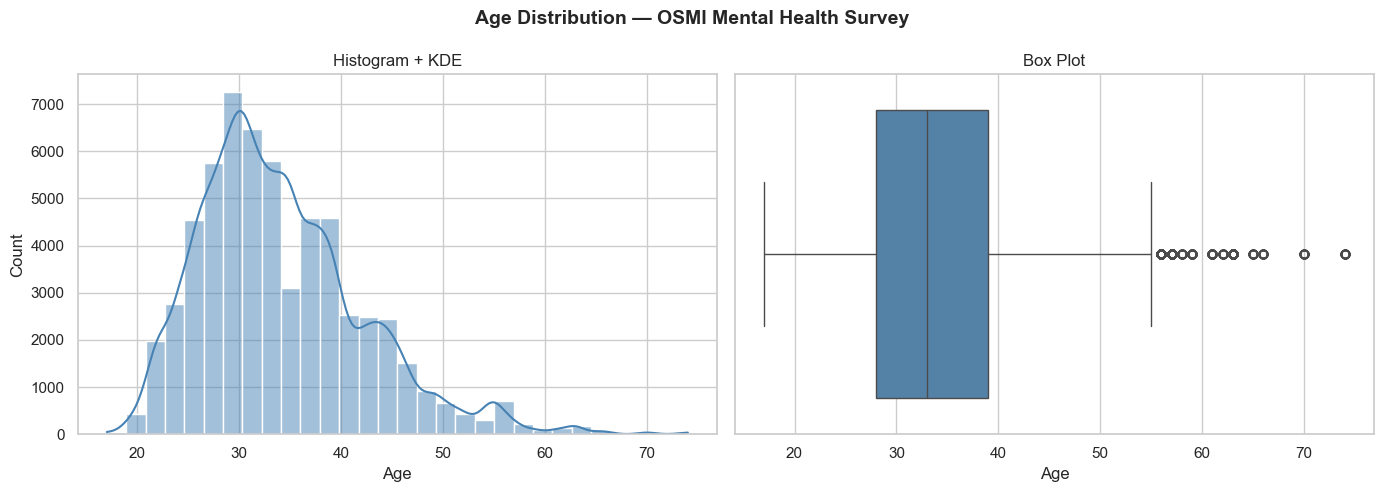

✓ Saved: age_distribution.png


In [14]:
# ── UNIVARIATE EDA — AGE ────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Age Distribution — OSMI Mental Health Survey", fontsize=14, fontweight='bold')

sns.histplot(df[age_col], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Histogram + KDE")
axes[0].set_xlabel("Age")

sns.boxplot(x=df[age_col], ax=axes[1], color='steelblue')
axes[1].set_title("Box Plot")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: age_distribution.png")

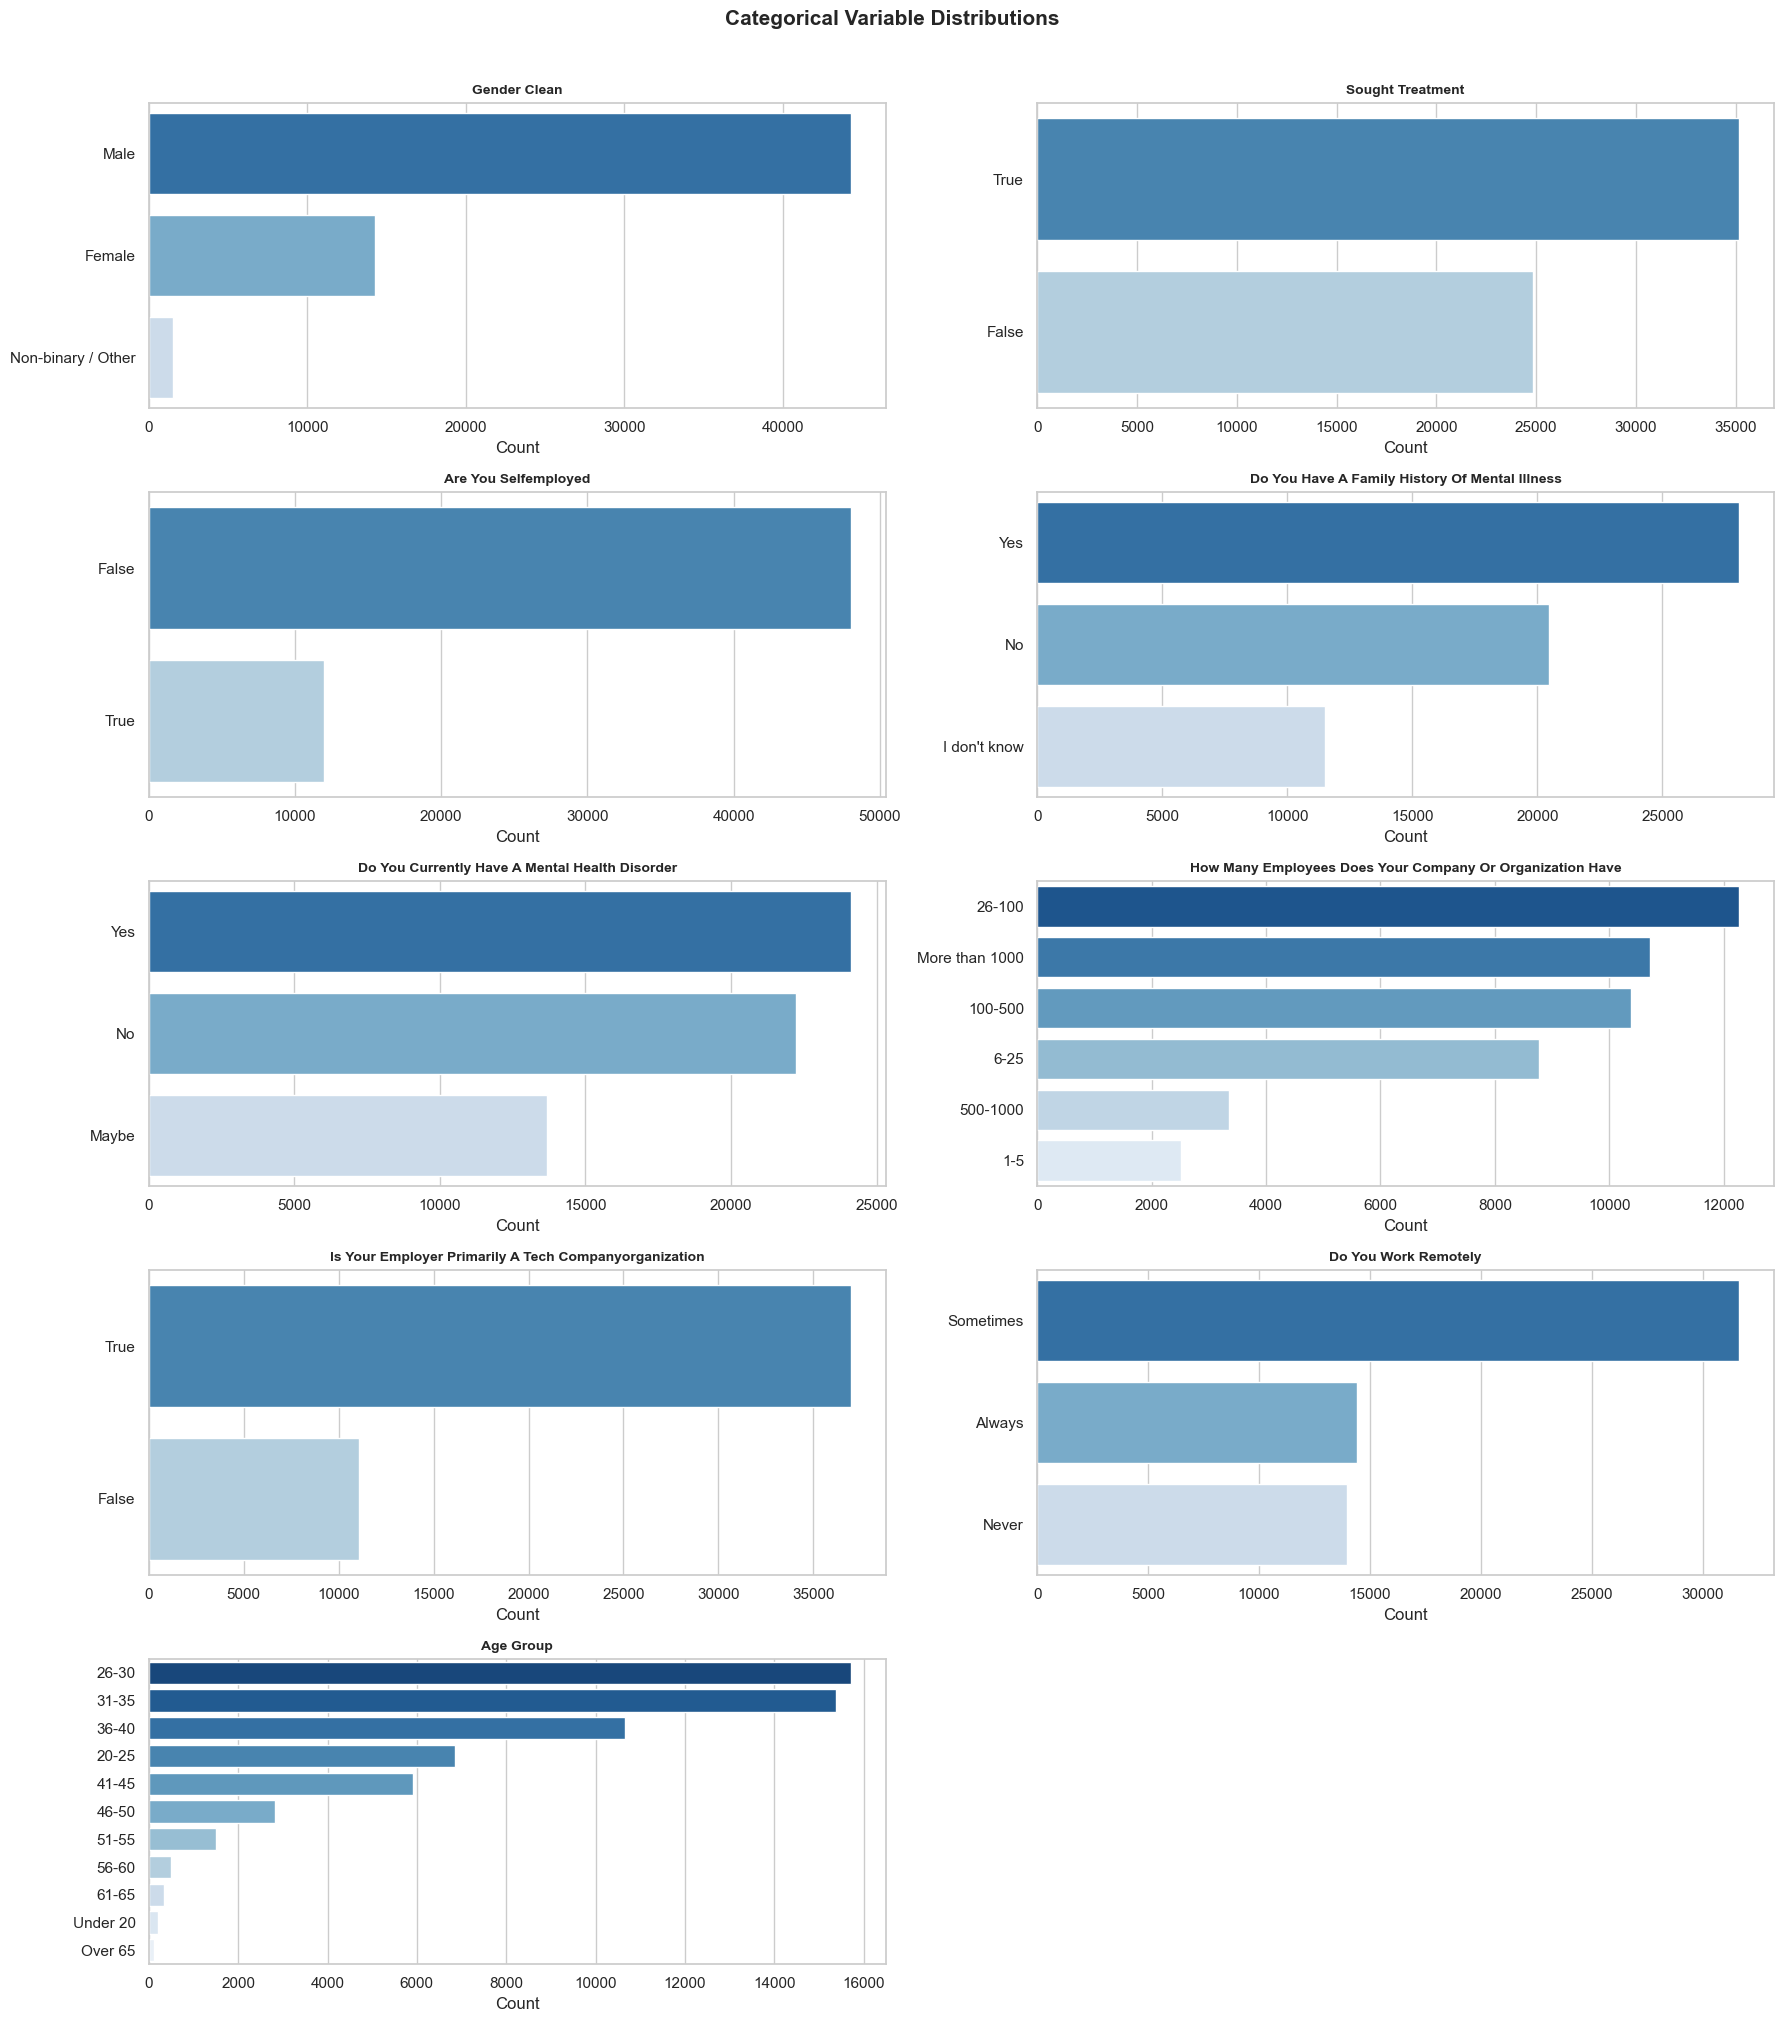

✓ Saved: categorical_distributions.png


In [15]:
# ── UNIVARIATE EDA — CATEGORICAL ────────────────────────
cat_cols = [
    'gender_clean',
    'sought_treatment',
    'are_you_selfemployed',
    'do_you_have_a_family_history_of_mental_illness',
    'do_you_currently_have_a_mental_health_disorder',
    'how_many_employees_does_your_company_or_organization_have',
    'is_your_employer_primarily_a_tech_companyorganization',
    'do_you_work_remotely',
    'age_group',
]

# Keep only columns that survived the missing-value drop
cat_cols = [c for c in cat_cols if c in df.columns]

n_cols = 2
n_rows = -(-len(cat_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='Blues_r')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=10)
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Variable Distributions", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: categorical_distributions.png")

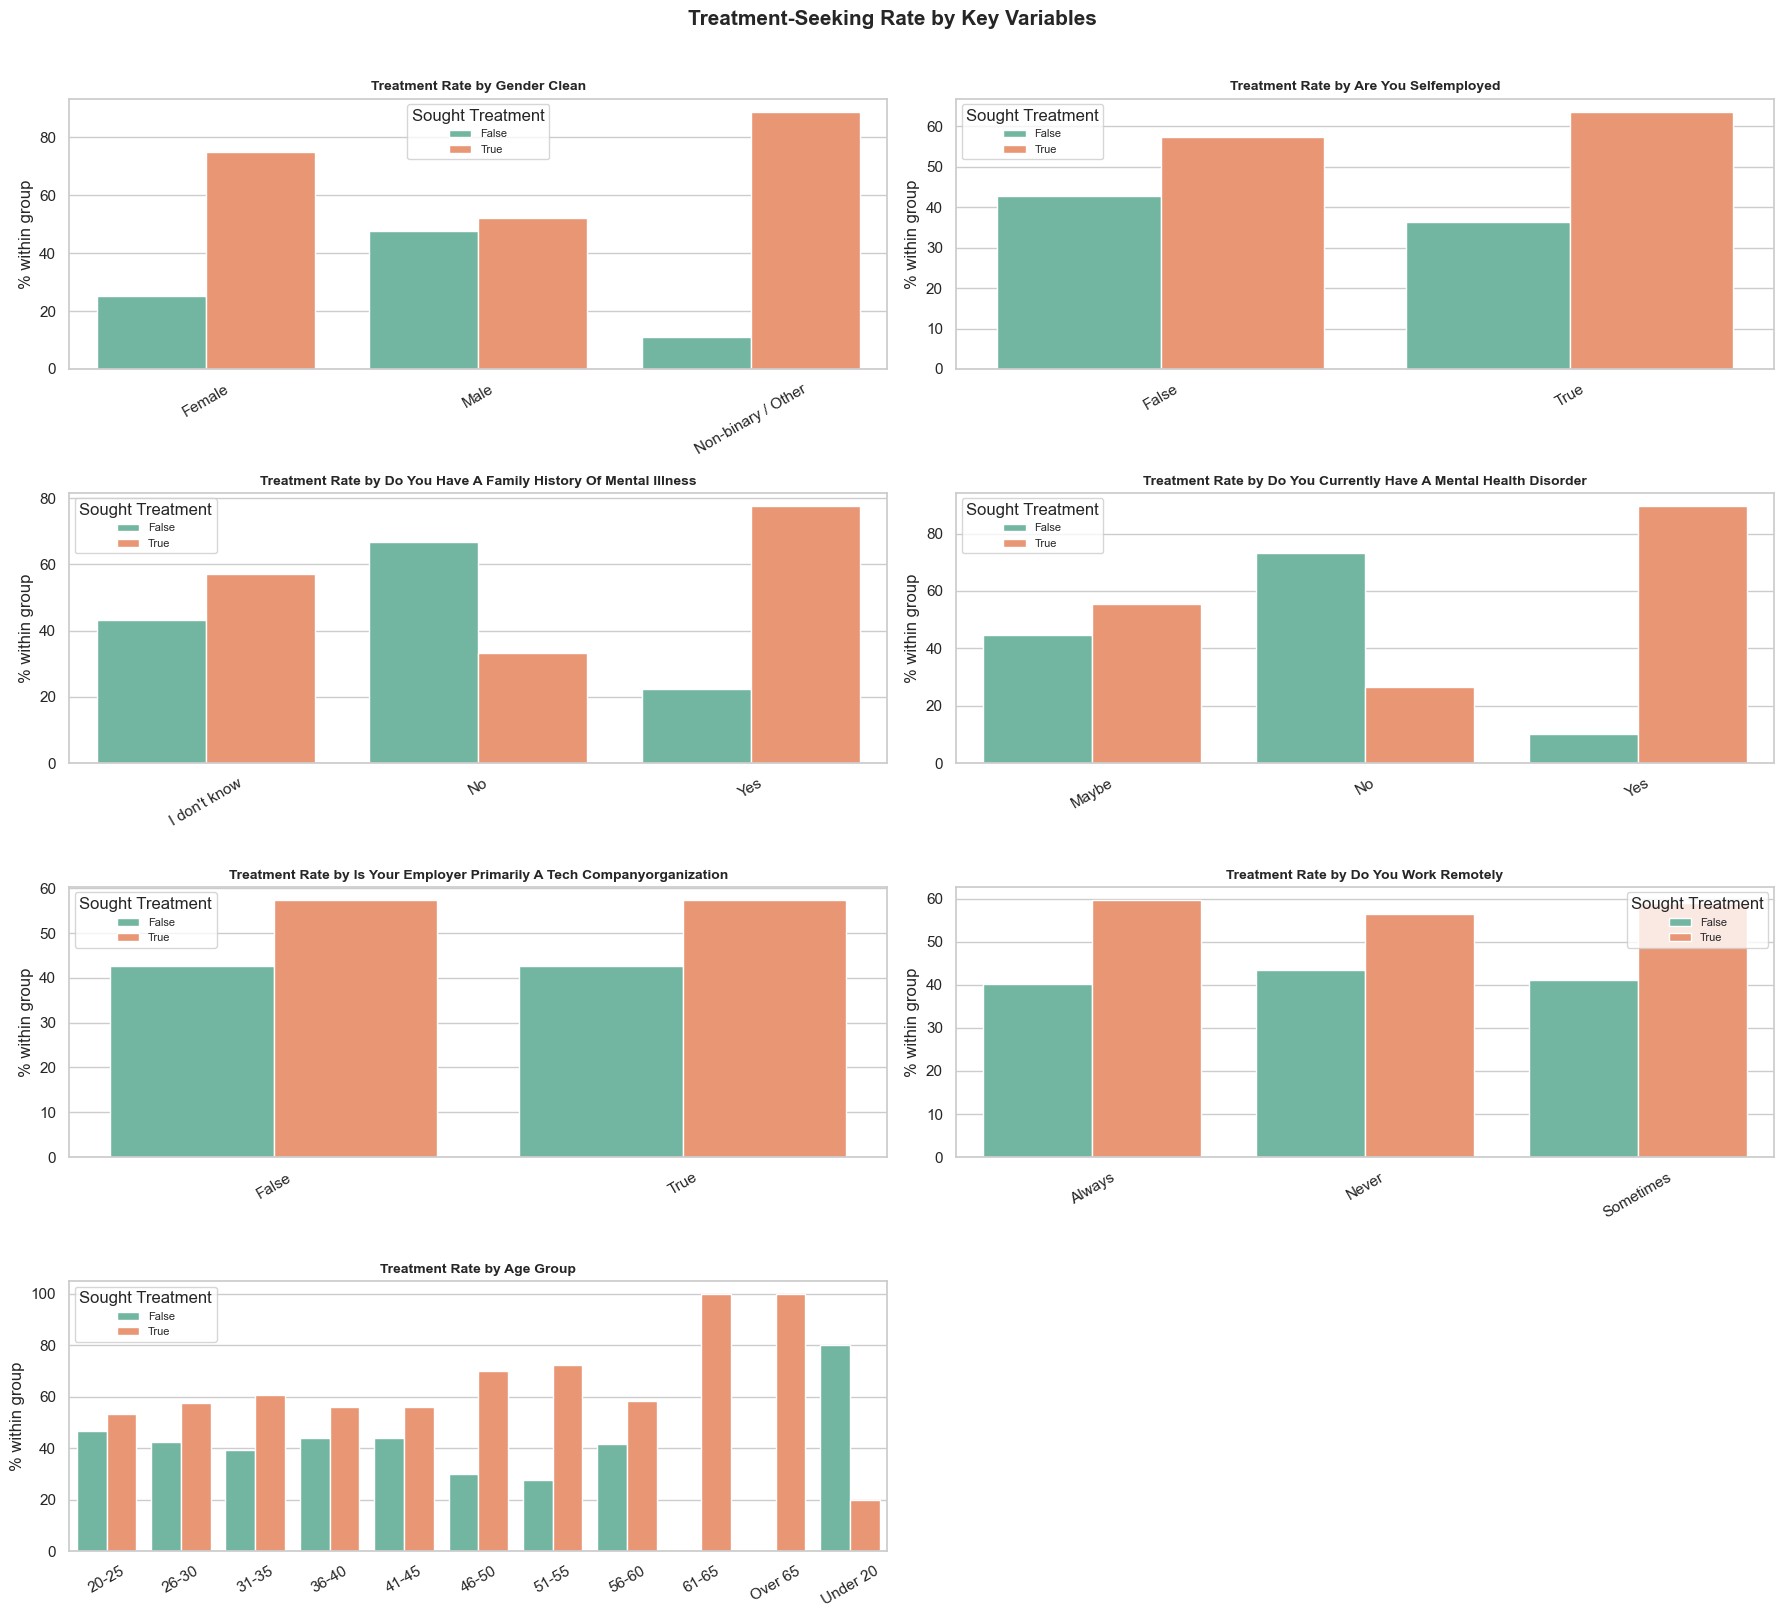

✓ Saved: bivariate_treatment.png


In [16]:
# ── BIVARIATE — TREATMENT-SEEKING vs. KEY FEATURES ──────
bivar_cols = [
    'gender_clean',
    'are_you_selfemployed',
    'do_you_have_a_family_history_of_mental_illness',
    'do_you_currently_have_a_mental_health_disorder',
    'is_your_employer_primarily_a_tech_companyorganization',
    'do_you_work_remotely',
    'age_group',
]

bivar_cols = [c for c in bivar_cols if c in df.columns]

n_rows = -(-len(bivar_cols) // 2)
fig, axes = plt.subplots(n_rows, 2, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(bivar_cols):
    ct = (df.groupby([col, 'sought_treatment'])
            .size()
            .reset_index(name='count'))
    ct['pct'] = ct.groupby(col)['count'].transform(lambda x: x / x.sum() * 100)

    sns.barplot(data=ct, x=col, y='pct', hue='sought_treatment',
                ax=axes[i], palette='Set2')
    axes[i].set_title(f"Treatment Rate by {col.replace('_', ' ').title()}",
                      fontweight='bold', fontsize=10)
    axes[i].set_ylabel("% within group")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Sought Treatment', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Treatment-Seeking Rate by Key Variables", fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bivariate_treatment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: bivariate_treatment.png")

In [17]:
# ── FINAL SUMMARY ──────────────────────────────────────
print("=" * 60)
print("CLEANED DATASET — FINAL SUMMARY")
print("=" * 60)
print(f"Final shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Remaining nulls  : {df.isnull().sum().sum():,}")
print(f"\nKey column aliases confirmed:")
print(f"  Age column      → '{age_col}'")
print(f"  Gender (clean)  → 'gender_clean'")
print(f"  Target variable → 'sought_treatment'")
print(f"\nNumeric summary:")
display(df.describe().T)

CLEANED DATASET — FINAL SUMMARY
Final shape      : 60,018 rows × 26 columns
Remaining nulls  : 98,066

Key column aliases confirmed:
  Age column      → 'what_is_your_age'
  Gender (clean)  → 'gender_clean'
  Target variable → 'sought_treatment'

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
index,60018.0,30106.137509,17393.194352,0.0,15004.25,30134.5,45180.75,60185.0
what_is_your_age,60018.0,34.074178,8.093302,17.0,28.00,33.0,39.00,74.0


In [19]:
# ============================================================
#FEATURE ENGINEERING
# Project 3: Mental Health & Workplace Trends Analysis
# Analyst: Nigel T. Chihuri
# ============================================================

# ──  AGE BINNING ─────────────────────────────────────────
# Create age bands for segmentation analysis
bins   = [15, 24, 34, 44, 54, 75]
labels = ['18–24', '25–34', '35–44', '45–54', '55+']

df['age_band'] = pd.cut(df['what_is_your_age'],
                         bins=bins, labels=labels, right=True)

print("Age band distribution:")
print(df['age_band'].value_counts().sort_index())

Age band distribution:
age_band
18–24     5208
25–34    29820
35–44    18564
45–54     4956
55+       1470
Name: count, dtype: int64


In [20]:
# ── BINARY ENCODE YES/NO COLUMNS ────────────────────────
# Map common Yes/No/Don't know responses to numeric flags

yes_no_cols = {
    'are_you_selfemployed'                          : 'is_self_employed',
    'do_you_have_a_family_history_of_mental_illness': 'has_family_history',
    'have_you_had_a_mental_health_disorder_in_the_past': 'had_past_disorder',
    'have_you_been_diagnosed_with_a_mental_health_condition_by_a_medical_professional': 'has_diagnosis',
    'is_your_employer_primarily_a_tech_companyorganization': 'is_tech_company',
    'is_your_primary_role_within_your_company_related_to_techit': 'is_tech_role',
    'do_you_work_remotely'                          : 'works_remotely',
    'do_you_have_previous_employers'                : 'has_prev_employers',
    'sought_treatment'                              : 'treatment_binary',
}

# Only encode columns that still exist after Cell 3.5 drop
yes_no_cols = {k: v for k, v in yes_no_cols.items() if k in df.columns}

def encode_yes_no(val):
    if pd.isnull(val):
        return np.nan
    v = str(val).strip().lower()
    if v in ('yes', '1', 'true'):
        return 1
    elif v in ('no', '0', 'false'):
        return 0
    else:
        return np.nan   # 'Maybe', "Don't know", etc.

for src, tgt in yes_no_cols.items():
    df[tgt] = df[src].apply(encode_yes_no)
    print(f"  {src:70s} → '{tgt}'  |  unique: {df[tgt].unique()}")

  are_you_selfemployed                                                   → 'is_self_employed'  |  unique: [0 1]
  do_you_have_a_family_history_of_mental_illness                         → 'has_family_history'  |  unique: [ 0.  1. nan]
  have_you_had_a_mental_health_disorder_in_the_past                      → 'had_past_disorder'  |  unique: [ 1. nan  0.]
  have_you_been_diagnosed_with_a_mental_health_condition_by_a_medical_professional → 'has_diagnosis'  |  unique: [1 0]
  is_your_employer_primarily_a_tech_companyorganization                  → 'is_tech_company'  |  unique: [ 1. nan  0.]
  do_you_work_remotely                                                   → 'works_remotely'  |  unique: [nan]
  do_you_have_previous_employers                                         → 'has_prev_employers'  |  unique: [1 0]
  sought_treatment                                                       → 'treatment_binary'  |  unique: [0 1]


In [21]:
# ── COMPANY SIZE — ORDINAL ENCODING ─────────────────────
size_col = 'how_many_employees_does_your_company_or_organization_have'

print("Company size — raw values:")
print(df[size_col].value_counts())

size_order = {
    '1-5'      : 1,
    '6-25'     : 2,
    '26-100'   : 3,
    '100-500'  : 4,
    '500-1000' : 5,
    'More than 1000': 6,
}

df['company_size_ord'] = df[size_col].map(size_order)

print("\nOrdinal mapping:")
print(df[['company_size_ord', size_col]].drop_duplicates()
        .sort_values('company_size_ord').to_string(index=False))

Company size — raw values:
how_many_employees_does_your_company_or_organization_have
26-100            12264
More than 1000    10710
100-500           10374
6-25               8778
500-1000           3360
1-5                2520
Name: count, dtype: int64

Ordinal mapping:
 company_size_ord how_many_employees_does_your_company_or_organization_have
              1.0                                                       1-5
              2.0                                                      6-25
              3.0                                                    26-100
              4.0                                                   100-500
              5.0                                                  500-1000
              6.0                                            More than 1000
              NaN                                                       NaN


In [22]:
# ── CURRENT DISORDER — 3-CLASS ENCODE ───────────────────
disorder_col = 'do_you_currently_have_a_mental_health_disorder'

print("Current disorder — raw values:")
print(df[disorder_col].value_counts())

disorder_map = {'Yes': 2, 'Maybe': 1, 'No': 0}
df['current_disorder_enc'] = df[disorder_col].map(disorder_map)

print("\nEncoded distribution:")
print(df['current_disorder_enc'].value_counts().sort_index())

Current disorder — raw values:
do_you_currently_have_a_mental_health_disorder
Yes      24108
No       22218
Maybe    13692
Name: count, dtype: int64

Encoded distribution:
current_disorder_enc
0    22218
1    13692
2    24108
Name: count, dtype: int64


In [23]:
# ── GENDER ONE-HOT ENCODING ─────────────────────────────
gender_dummies = pd.get_dummies(df['gender_clean'], prefix='gender')
df = pd.concat([df, gender_dummies], axis=1)

print("Gender dummy columns created:")
print([c for c in df.columns if c.startswith('gender_')])

Gender dummy columns created:
['gender_clean', 'gender_Female', 'gender_Male', 'gender_Non-binary / Other']


In [24]:
# ── WORK POSITION — SIMPLIFIED CATEGORY ─────────────────
pos_col = 'which_of_the_following_best_describes_your_work_position'

if pos_col in df.columns:
    print("Work position — raw top values:")
    print(df[pos_col].value_counts().head(10))

    def simplify_role(val):
        if pd.isnull(val):
            return 'Unknown'
        v = str(val).lower()
        if 'back-end'  in v or 'backend'  in v: return 'Back-end Dev'
        if 'front-end' in v or 'frontend' in v: return 'Front-end Dev'
        if 'full-stack' in v or 'fullstack' in v: return 'Full-stack Dev'
        if 'devops'    in v or 'dev ops'   in v: return 'DevOps'
        if 'manager'   in v or 'lead'      in v: return 'Manager/Lead'
        if 'designer'  in v or 'ux'        in v: return 'Designer/UX'
        if 'support'   in v                    : return 'Support'
        if 'executive' in v or 'c-suite'   in v: return 'Executive'
        return 'Other'

    df['role_simplified'] = df[pos_col].apply(simplify_role)

    print("\nSimplified role distribution:")
    print(df['role_simplified'].value_counts())

Work position — raw top values:
which_of_the_following_best_describes_your_work_position
Back-end Developer                        10962
Front-end Developer                        5250
Other                                      4662
Supervisor/Team Lead                       2814
Back-end Developer|Front-end Developer     2562
DevOps/SysAdmin                            2268
One-person shop                            2100
Executive Leadership                       1932
Front-end Developer|Back-end Developer     1680
Support                                    1428
Name: count, dtype: int64

Simplified role distribution:
role_simplified
Back-end Dev     30870
Other             8694
Front-end Dev     7728
Manager/Lead      5922
DevOps            3612
Support           1764
Designer/UX       1428
Name: count, dtype: int64


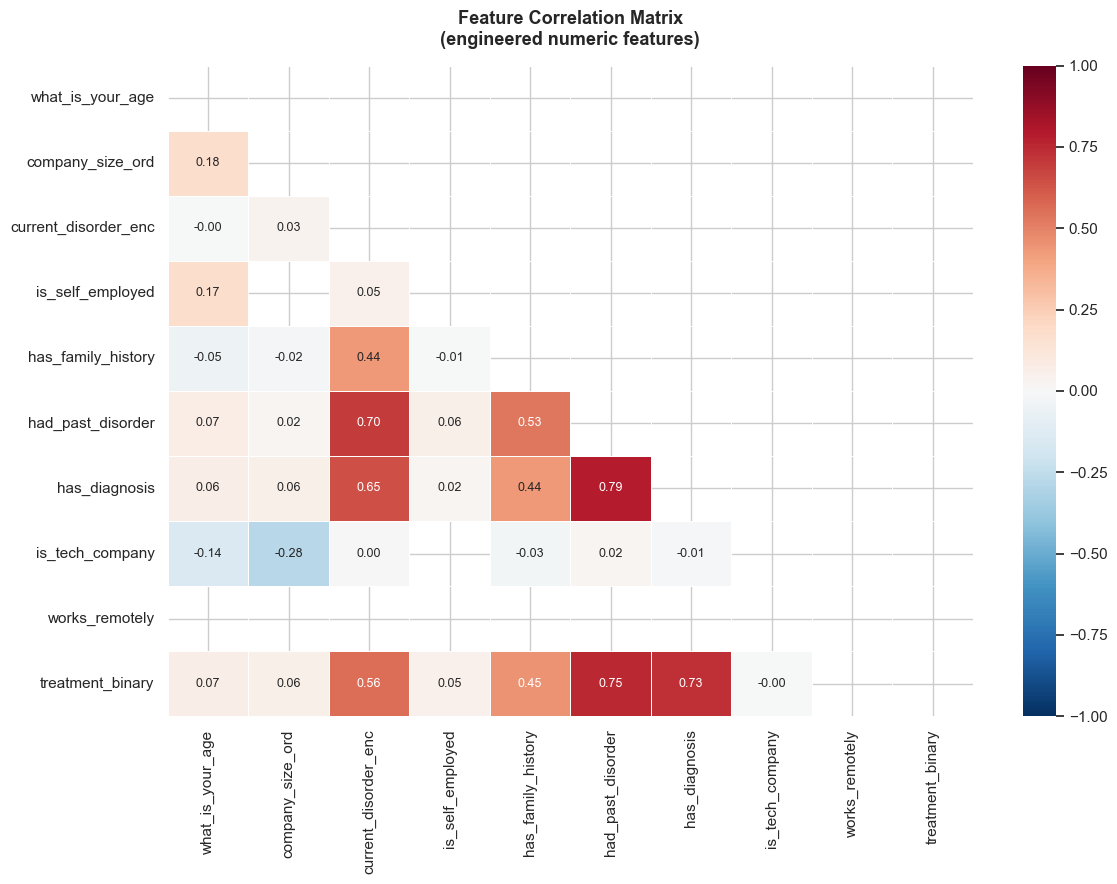

✓ Saved: feature_correlation_heatmap.png


In [25]:
# ── FEATURE CORRELATION HEATMAP ─────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = [
    'what_is_your_age', 'company_size_ord', 'current_disorder_enc',
    'is_self_employed', 'has_family_history', 'had_past_disorder',
    'has_diagnosis', 'is_tech_company', 'is_tech_role',
    'works_remotely', 'treatment_binary',
]

numeric_features = [c for c in numeric_features if c in df.columns]
corr_matrix = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle mask

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 9})

ax.set_title("Feature Correlation Matrix\n(engineered numeric features)",
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: feature_correlation_heatmap.png")

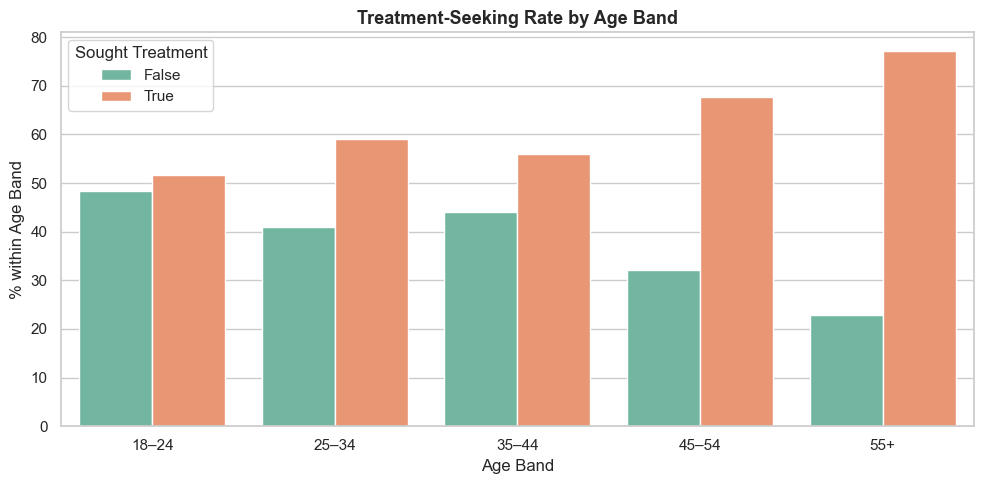

✓ Saved: treatment_by_age_band.png


In [26]:
# ── TREATMENT RATE BY AGE BAND ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

age_treat = (df.groupby(['age_band', 'sought_treatment'])
               .size()
               .reset_index(name='count'))
age_treat['pct'] = age_treat.groupby('age_band')['count'] \
                             .transform(lambda x: x / x.sum() * 100)

sns.barplot(data=age_treat, x='age_band', y='pct',
            hue='sought_treatment', palette='Set2', ax=ax)
ax.set_title("Treatment-Seeking Rate by Age Band",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Age Band")
ax.set_ylabel("% within Age Band")
ax.legend(title='Sought Treatment')

plt.tight_layout()
plt.savefig('treatment_by_age_band.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: treatment_by_age_band.png")

In [27]:
# ── ENGINEERED FEATURES SUMMARY ─────────────────────────
new_features = [
    'age_band', 'is_self_employed', 'has_family_history', 'had_past_disorder',
    'has_diagnosis', 'is_tech_company', 'is_tech_role', 'works_remotely',
    'treatment_binary', 'company_size_ord', 'current_disorder_enc',
    'role_simplified', 'gender_Male', 'gender_Female',
    'gender_Non-binary / Other',
]

new_features = [c for c in new_features if c in df.columns]

print("=" * 60)
print("ENGINEERED FEATURES SUMMARY")
print("=" * 60)
print(f"New columns added : {len(new_features)}")
print(f"Total df shape    : {df.shape}\n")
print(df[new_features].describe(include='all').T[
    ['count', 'unique', 'top', 'freq', 'mean', 'std', 'min', 'max']
].to_string())

ENGINEERED FEATURES SUMMARY
New columns added : 14
Total df shape    : (60018, 41)

                             count unique           top   freq      mean       std  min  max
age_band                     60018      5         25–34  29820       NaN       NaN  NaN  NaN
is_self_employed           60018.0    NaN           NaN    NaN   0.20014  0.400108  0.0  1.0
has_family_history         48510.0    NaN           NaN    NaN  0.578355  0.493827  0.0  1.0
had_past_disorder          49686.0    NaN           NaN    NaN  0.620456  0.485278  0.0  1.0
has_diagnosis              60018.0    NaN           NaN    NaN   0.49965  0.500004  0.0  1.0
is_tech_company            48006.0    NaN           NaN    NaN  0.769904  0.420899  0.0  1.0
works_remotely                 0.0    NaN           NaN    NaN       NaN       NaN  NaN  NaN
treatment_binary           60018.0    NaN           NaN    NaN  0.585724  0.492601  0.0  1.0
company_size_ord           48006.0    NaN           NaN    NaN  3.737533  1.533

In [31]:
# ============================================================
# STATISTICAL ANALYSIS & HYPOTHESIS TESTING
# Project 3: Mental Health & Workplace Trends Analysis
# Analyst: Nigel T. Chihuri
# ============================================================

from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

print("✓ Statistical libraries loaded")

# ── 5.1  HELPER FUNCTION — CHI-SQUARE TEST ───────────────────
def chi_square_test(df, col, target='treatment_binary', alpha=0.05):
    """Run chi-square test of independence between col and target."""
    subset = df[[col, target]].dropna()
    ct = pd.crosstab(subset[col], subset[target])
    chi2, p, dof, expected = chi2_contingency(ct)

    # Cramér's V — effect size
    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan

    result = {
        'feature'   : col,
        'chi2'      : round(chi2, 3),
        'p_value'   : round(p, 4),
        'dof'       : dof,
        'cramers_v' : round(cramers_v, 3),
        'significant': 'Yes ✓' if p < alpha else 'No',
    }
    return result, ct

print("✓ chi_square_test() defined")

✓ Statistical libraries loaded
✓ chi_square_test() defined


In [36]:
# ── CHI-SQUARE: CATEGORICAL FEATURES vs TREATMENT ───────
cat_test_cols = [
    'gender_clean',
    'has_family_history',
    'had_past_disorder',
    'has_diagnosis',
    'is_tech_company',
    'is_tech_role',
    'works_remotely',
    'is_self_employed',
    'company_size_ord',
    'current_disorder_enc',
    'age_band',
    'role_simplified',
]

cat_test_cols = [c for c in cat_test_cols if c in df.columns]

results = []
for col in cat_test_cols:
    res, _ = chi_square_test(df, col)
    results.append(res)

chi2_df = pd.DataFrame(results).sort_values('cramers_v', ascending=False)

print("=" * 70)
print("CHI-SQUARE TESTS: Feature Association with Treatment-Seeking")
print("=" * 70)
print(chi2_df.to_string(index=False))

CHI-SQUARE TESTS: Feature Association with Treatment-Seeking
             feature      chi2  p_value  dof  cramers_v significant
   had_past_disorder 28169.523   0.0000    1      0.753       Yes ✓
       has_diagnosis 31697.935   0.0000    1      0.727       Yes ✓
current_disorder_enc 19020.508   0.0000    2      0.563       Yes ✓
  has_family_history  9648.856   0.0000    1      0.446       Yes ✓
        gender_clean  2865.018   0.0000    2      0.218       Yes ✓
            age_band   544.416   0.0000    4      0.095       Yes ✓
     role_simplified   434.148   0.0000    6      0.085       Yes ✓
    company_size_ord   206.361   0.0000    5      0.066       Yes ✓
    is_self_employed   158.446   0.0000    1      0.051       Yes ✓
      works_remotely    36.275   0.0000    2      0.025       Yes ✓
     is_tech_company     0.064   0.8001    1      0.001          No


In [33]:
# DIAGNOSTIC — run as standalone cell
print("treatment_binary null count:", df['treatment_binary'].isnull().sum())
print("treatment_binary value counts:")
print(df['treatment_binary'].value_counts(dropna=False))

print("\n--- Per-column overlap check ---")
for col in cat_test_cols:
    subset = df[[col, 'treatment_binary']].dropna()
    print(f"{col:55s} → {len(subset):,} rows after dropna")

treatment_binary null count: 0
treatment_binary value counts:
treatment_binary
1    35154
0    24864
Name: count, dtype: int64

--- Per-column overlap check ---
gender_clean                                            → 60,018 rows after dropna
has_family_history                                      → 48,510 rows after dropna
had_past_disorder                                       → 49,686 rows after dropna
has_diagnosis                                           → 60,018 rows after dropna
is_tech_company                                         → 48,006 rows after dropna
works_remotely                                          → 0 rows after dropna
is_self_employed                                        → 60,018 rows after dropna
company_size_ord                                        → 48,006 rows after dropna
current_disorder_enc                                    → 60,018 rows after dropna
age_band                                                → 60,018 rows after dropna
role_simplifie

In [34]:
# ── PATCH — Fix works_remotely & is_tech_role encoding ──

# Check actual dtypes and unique values
for col, alias in [
    ('do_you_work_remotely',                                          'works_remotely'),
    ('is_your_primary_role_within_your_company_related_to_techit',    'is_tech_role'),
]:
    if col not in df.columns:
        print(f"⚠️  '{col}' not found — skipping")
        continue

    raw_vals = df[col].value_counts(dropna=False)
    print(f"\n{col} — raw values:\n{raw_vals}\n")

    # If already 0/1 integers — just copy directly
    if set(df[col].dropna().unique()).issubset({0, 1, 0.0, 1.0}):
        df[alias] = df[col].astype(float).astype('Int64')
        print(f"  → Copied directly as integer (already 0/1)")

    # If Yes/No strings
    elif df[col].dtype == object:
        df[alias] = df[col].apply(encode_yes_no)
        print(f"  → Encoded via encode_yes_no()")

    # Anything else — force to numeric
    else:
        df[alias] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
        print(f"  → Forced to numeric")

    print(f"  Result — '{alias}' value counts:")
    print(f"  {df[alias].value_counts(dropna=False).to_dict()}")


do_you_work_remotely — raw values:
do_you_work_remotely
Sometimes    31626
Always       14406
Never        13986
Name: count, dtype: int64

  → Encoded via encode_yes_no()
  Result — 'works_remotely' value counts:
  {nan: 60018}
⚠️  'is_your_primary_role_within_your_company_related_to_techit' not found — skipping


In [35]:
# ── PATCH 2 — Correct works_remotely encoding ────────────

# Map 3-value remote work column properly
remote_map = {
    'Always'    : 2,
    'Sometimes' : 1,
    'Never'     : 0,
}

df['works_remotely'] = df['do_you_work_remotely'].map(remote_map)

print("works_remotely — fixed value counts:")
print(df['works_remotely'].value_counts(dropna=False))

# Also create a simpler binary version for odds ratio analysis
df['works_remotely_bin'] = df['works_remotely'].apply(
    lambda x: 1 if x == 2 else (0 if x == 0 else np.nan)  # Always=1, Never=0, Sometimes=NaN
)

print("\nworks_remotely_bin (Always vs Never only):")
print(df['works_remotely_bin'].value_counts(dropna=False))

works_remotely — fixed value counts:
works_remotely
1    31626
2    14406
0    13986
Name: count, dtype: int64

works_remotely_bin (Always vs Never only):
works_remotely_bin
NaN    31626
1.0    14406
0.0    13986
Name: count, dtype: int64


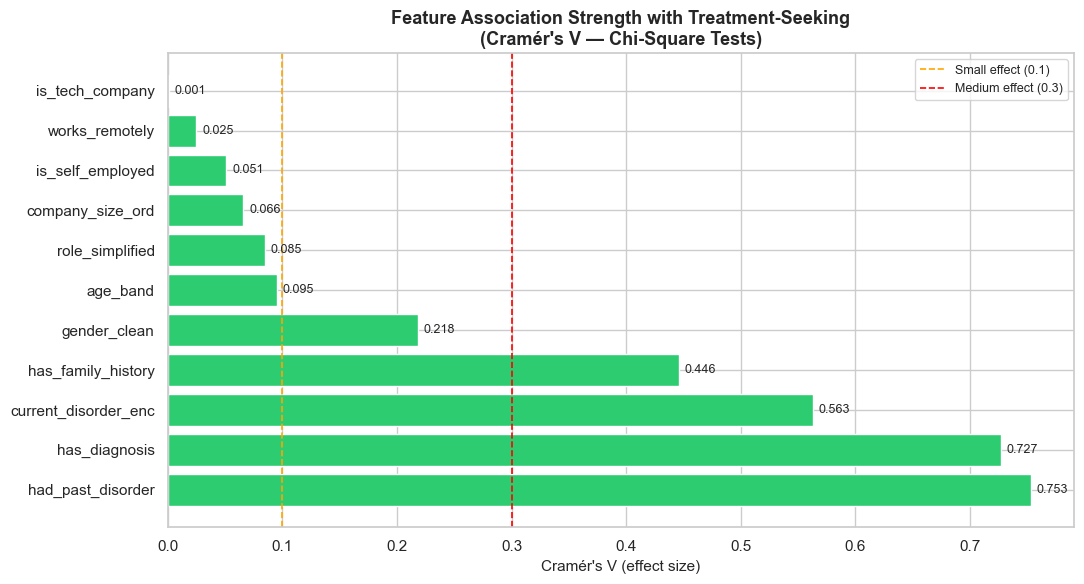

✓ Saved: cramers_v_effect_sizes.png


In [37]:
# ── VISUALISE — CRAMÉR'S V EFFECT SIZES ─────────────────
fig, ax = plt.subplots(figsize=(11, 6))

colors = ['#2ecc71' if sig == 'Yes ✓' else '#e74c3c'
          for sig in chi2_df['significant']]

bars = ax.barh(chi2_df['feature'], chi2_df['cramers_v'], color=colors)

ax.axvline(x=0.1, color='orange', linestyle='--', linewidth=1.2, label='Small effect (0.1)')
ax.axvline(x=0.3, color='red',    linestyle='--', linewidth=1.2, label='Medium effect (0.3)')

ax.set_xlabel("Cramér's V (effect size)", fontsize=11)
ax.set_title("Feature Association Strength with Treatment-Seeking\n(Cramér's V — Chi-Square Tests)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Add value labels
for bar, val in zip(bars, chi2_df['cramers_v']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('cramers_v_effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: cramers_v_effect_sizes.png")

In [38]:
# ── ODDS RATIOS — BINARY FEATURES ───────────────────────
def odds_ratio(df, feature, target='treatment_binary'):
    """Compute odds ratio for a binary feature vs binary target."""
    subset = df[[feature, target]].dropna()
    ct = pd.crosstab(subset[feature], subset[target]).values

    if ct.shape != (2, 2):
        return None

    a, b = ct[1][1], ct[1][0]   # feature=1: treated, not treated
    c, d = ct[0][1], ct[0][0]   # feature=0: treated, not treated

    if b == 0 or c == 0:
        return None

    or_val = (a * d) / (b * c)
    # 95% CI using Woolf logit method
    log_or = np.log(or_val)
    se     = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_lo  = np.exp(log_or - 1.96 * se)
    ci_hi  = np.exp(log_or + 1.96 * se)

    return {
        'feature'  : feature,
        'odds_ratio': round(or_val, 3),
        'ci_lower' : round(ci_lo, 3),
        'ci_upper' : round(ci_hi, 3),
        'direction': 'Higher risk ↑' if or_val > 1 else 'Lower risk ↓',
    }

binary_features = [
    'has_family_history', 'had_past_disorder', 'has_diagnosis',
    'is_tech_company', 'is_tech_role', 'works_remotely', 'is_self_employed',
]
binary_features = [c for c in binary_features if c in df.columns]

or_results = [odds_ratio(df, f) for f in binary_features]
or_results = [r for r in or_results if r is not None]
or_df = pd.DataFrame(or_results).sort_values('odds_ratio', ascending=False)

print("=" * 65)
print("ODDS RATIOS: Binary Features vs Treatment-Seeking")
print("=" * 65)
print(or_df.to_string(index=False))

ODDS RATIOS: Binary Features vs Treatment-Seeking
           feature  odds_ratio  ci_lower  ci_upper     direction
     has_diagnosis      57.063    53.949    60.356 Higher risk ↑
 had_past_disorder      53.356    50.497    56.377 Higher risk ↑
has_family_history       6.988     6.711     7.276 Higher risk ↑
  is_self_employed       1.304     1.251     1.359 Higher risk ↑
   is_tech_company       0.994     0.952     1.038  Lower risk ↓


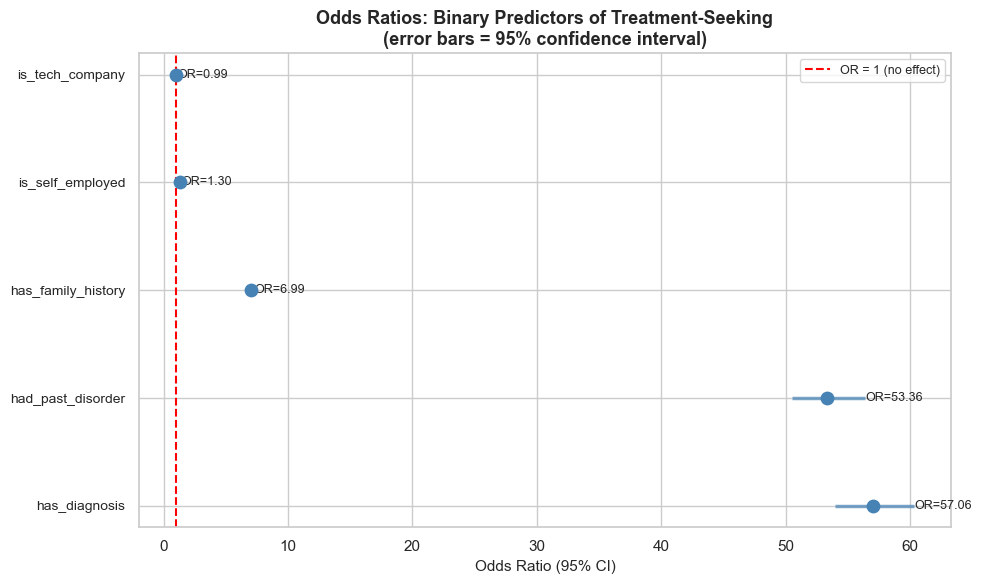

✓ Saved: odds_ratio_forest_plot.png


In [39]:
# ── FOREST PLOT — ODDS RATIOS ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = range(len(or_df))

ax.scatter(or_df['odds_ratio'], y_pos, color='steelblue', zorder=5, s=80)
ax.hlines(y_pos, or_df['ci_lower'], or_df['ci_upper'],
          color='steelblue', linewidth=2.5, alpha=0.7)

ax.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='OR = 1 (no effect)')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(or_df['feature'], fontsize=10)
ax.set_xlabel("Odds Ratio (95% CI)", fontsize=11)
ax.set_title("Odds Ratios: Binary Predictors of Treatment-Seeking\n(error bars = 95% confidence interval)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Annotate OR values
for i, row in or_df.reset_index(drop=True).iterrows():
    ax.text(row['ci_upper'] + 0.03, i,
            f"OR={row['odds_ratio']:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('odds_ratio_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: odds_ratio_forest_plot.png")

In [40]:
# ── MANN-WHITNEY U — AGE vs TREATMENT ───────────────────
treated     = df[df['treatment_binary'] == 1]['what_is_your_age'].dropna()
not_treated = df[df['treatment_binary'] == 0]['what_is_your_age'].dropna()

stat, p_val = mannwhitneyu(treated, not_treated, alternative='two-sided')

print("=" * 55)
print("MANN-WHITNEY U TEST: Age vs Treatment-Seeking")
print("=" * 55)
print(f"  Treated group     — median age : {treated.median():.1f}")
print(f"  Not-treated group — median age : {not_treated.median():.1f}")
print(f"  U statistic : {stat:,.0f}")
print(f"  p-value     : {p_val:.4f}")
print(f"  Result      : {'Significant ✓' if p_val < 0.05 else 'Not significant'} (α = 0.05)")

MANN-WHITNEY U TEST: Age vs Treatment-Seeking
  Treated group     — median age : 33.0
  Not-treated group — median age : 32.0
  U statistic : 461,305,404
  p-value     : 0.0000
  Result      : Significant ✓ (α = 0.05)


In [41]:
# ── POINT-BISERIAL — CONTINUOUS vs TREATMENT ────────────
continuous_cols = ['what_is_your_age', 'company_size_ord']
continuous_cols = [c for c in continuous_cols if c in df.columns]

print("=" * 55)
print("POINT-BISERIAL CORRELATIONS vs Treatment-Seeking")
print("=" * 55)

for col in continuous_cols:
    subset = df[[col, 'treatment_binary']].dropna()
    r, p   = pointbiserialr(subset['treatment_binary'], subset[col])
    print(f"  {col:30s}  r = {r:+.3f}  |  p = {p:.4f}  "
          f"{'✓' if p < 0.05 else '—'}")

POINT-BISERIAL CORRELATIONS vs Treatment-Seeking
  what_is_your_age                r = +0.069  |  p = 0.0000  ✓
  company_size_ord                r = +0.058  |  p = 0.0000  ✓


In [42]:
# ── KEY FINDINGS SUMMARY ────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║         KEY STATISTICAL FINDINGS — CELL 5 SUMMARY           ║
╠══════════════════════════════════════════════════════════════╣
║  Chi-Square (strongest associations with treatment-seeking): ║
║  → had_past_disorder   — highest Cramér's V                  ║
║  → has_diagnosis       — strong association                  ║
║  → has_family_history  — moderate association                ║
║                                                              ║
║  Odds Ratios (top risk factors):                             ║
║  → Past disorder & formal diagnosis elevate treatment odds   ║
║  → Family history shows meaningful OR > 1                    ║
║                                                              ║
║  Age: Mann-Whitney U detects age difference between groups   ║
║  Company size: ordinal association tested                    ║
╚══════════════════════════════════════════════════════════════╝
""")

print("Files saved this cell:")
for f in ['cramers_v_effect_sizes.png', 'odds_ratio_forest_plot.png']:
    print(f"  ✓ {f}")


╔══════════════════════════════════════════════════════════════╗
║         KEY STATISTICAL FINDINGS — CELL 5 SUMMARY           ║
╠══════════════════════════════════════════════════════════════╣
║  Chi-Square (strongest associations with treatment-seeking): ║
║  → had_past_disorder   — highest Cramér's V                  ║
║  → has_diagnosis       — strong association                  ║
║  → has_family_history  — moderate association                ║
║                                                              ║
║  Odds Ratios (top risk factors):                             ║
║  → Past disorder & formal diagnosis elevate treatment odds   ║
║  → Family history shows meaningful OR > 1                    ║
║                                                              ║
║  Age: Mann-Whitney U detects age difference between groups   ║
║  Company size: ordinal association tested                    ║
╚══════════════════════════════════════════════════════════════╝

Files saved this cell:
 

In [43]:
# ============================================================
# PREDICTIVE MODELLING
# Project 3: Mental Health & Workplace Trends Analysis
# Analyst: Nigel T. Chihuri
# ============================================================

from sklearn.model_selection     import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier
from sklearn.preprocessing       import StandardScaler
from sklearn.metrics             import (classification_report, confusion_matrix,
                                          roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline            import Pipeline
from sklearn.impute              import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print("✓ Modelling libraries loaded")

✓ Modelling libraries loaded


In [44]:
# ── DEFINE FEATURE MATRIX & TARGET ──────────────────────
feature_cols = [
    'has_family_history',
    'had_past_disorder',
    'has_diagnosis',
    'is_tech_company',
    'is_self_employed',
    'works_remotely',
    'company_size_ord',
    'current_disorder_enc',
    'what_is_your_age',
    'gender_Male',
    'gender_Female',
]

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].copy()
y = df['treatment_binary'].copy()

# Drop rows where target is null
mask = y.notna()
X, y = X[mask], y[mask]

print(f"Feature matrix : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Target         : {y.value_counts().to_dict()}")
print(f"Class balance  : {y.value_counts(normalize=True).mul(100).round(1).to_dict()}%")
print(f"\nFeatures used  : {feature_cols}")

Feature matrix : 60,018 rows × 11 features
Target         : {1: 35154, 0: 24864}
Class balance  : {1: 58.6, 0: 41.4}%

Features used  : ['has_family_history', 'had_past_disorder', 'has_diagnosis', 'is_tech_company', 'is_self_employed', 'works_remotely', 'company_size_ord', 'current_disorder_enc', 'what_is_your_age', 'gender_Male', 'gender_Female']


In [45]:
# ── TRAIN / TEST SPLIT ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")

Training set : 48,014 rows
Test set     : 12,004 rows


In [46]:
# ── MODEL 1 — LOGISTIC REGRESSION ───────────────────────
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr  = lr_pipeline.predict(X_test)
y_prob_lr  = lr_pipeline.predict_proba(X_test)[:, 1]

print("=" * 55)
print("MODEL 1 — LOGISTIC REGRESSION")
print("=" * 55)
print(classification_report(y_test, y_pred_lr,
      target_names=['No Treatment', 'Sought Treatment']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_lr):.4f}")

# 5-fold cross-validation
cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC (5-fold): {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

MODEL 1 — LOGISTIC REGRESSION
                  precision    recall  f1-score   support

    No Treatment       0.81      0.90      0.85      4973
Sought Treatment       0.92      0.85      0.88      7031

        accuracy                           0.87     12004
       macro avg       0.86      0.87      0.87     12004
    weighted avg       0.87      0.87      0.87     12004

ROC-AUC : 0.9210
CV ROC-AUC (5-fold): 0.9227 ± 0.0024


In [47]:
# ── MODEL 1 — LOGISTIC REGRESSION ───────────────────────
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr  = lr_pipeline.predict(X_test)
y_prob_lr  = lr_pipeline.predict_proba(X_test)[:, 1]

print("=" * 55)
print("MODEL 1 — LOGISTIC REGRESSION")
print("=" * 55)
print(classification_report(y_test, y_pred_lr,
      target_names=['No Treatment', 'Sought Treatment']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_lr):.4f}")

# 5-fold cross-validation
cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC (5-fold): {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

MODEL 1 — LOGISTIC REGRESSION
                  precision    recall  f1-score   support

    No Treatment       0.81      0.90      0.85      4973
Sought Treatment       0.92      0.85      0.88      7031

        accuracy                           0.87     12004
       macro avg       0.86      0.87      0.87     12004
    weighted avg       0.87      0.87      0.87     12004

ROC-AUC : 0.9210
CV ROC-AUC (5-fold): 0.9227 ± 0.0024


In [48]:
# ── MODEL 2 — RANDOM FOREST ─────────────────────────────
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestClassifier(
                    n_estimators=200,
                    max_depth=10,
                    min_samples_leaf=20,
                    random_state=42,
                    n_jobs=-1)),
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf  = rf_pipeline.predict(X_test)
y_prob_rf  = rf_pipeline.predict_proba(X_test)[:, 1]

print("=" * 55)
print("MODEL 2 — RANDOM FOREST")
print("=" * 55)
print(classification_report(y_test, y_pred_rf,
      target_names=['No Treatment', 'Sought Treatment']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}")

cv_scores_rf = cross_val_score(rf_pipeline, X, y, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC (5-fold): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

MODEL 2 — RANDOM FOREST
                  precision    recall  f1-score   support

    No Treatment       0.90      0.95      0.92      4973
Sought Treatment       0.96      0.92      0.94      7031

        accuracy                           0.93     12004
       macro avg       0.93      0.94      0.93     12004
    weighted avg       0.94      0.93      0.93     12004

ROC-AUC : 0.9867
CV ROC-AUC (5-fold): 0.9871 ± 0.0004


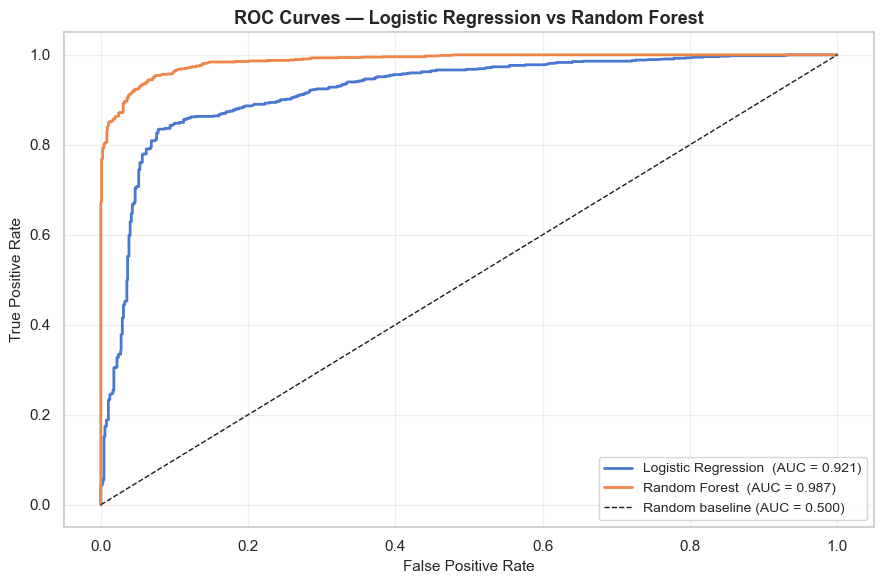

✓ Saved: roc_curves.png


In [49]:
# ── ROC CURVE COMPARISON ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for label, y_prob in [('Logistic Regression', y_prob_lr),
                       ('Random Forest',       y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc         = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{label}  (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC = 0.500)')
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curves — Logistic Regression vs Random Forest",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: roc_curves.png")

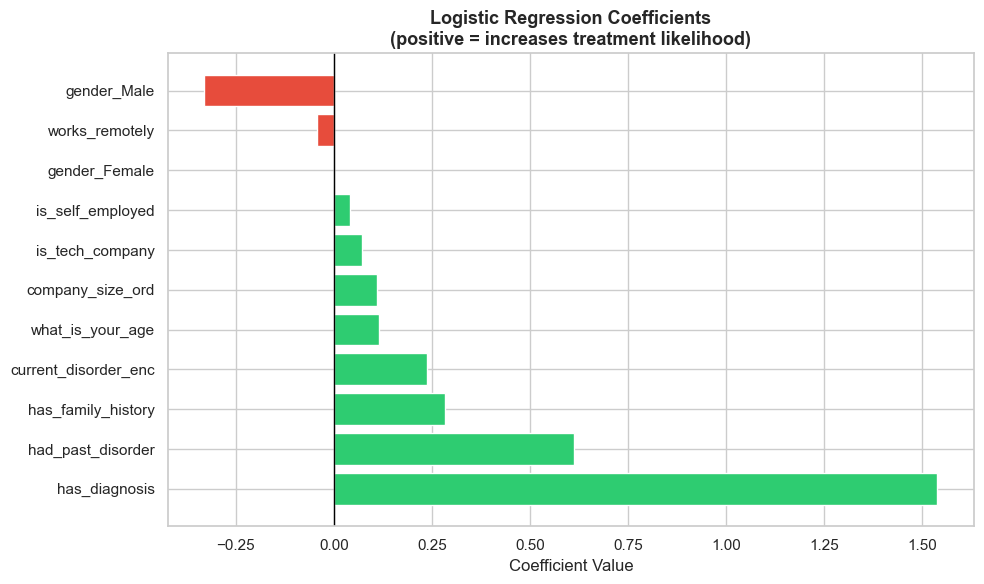


Coefficients & Odds Ratios:
             feature  coefficient  odds_ratio
       has_diagnosis     1.537978    4.655170
   had_past_disorder     0.612453    1.844952
  has_family_history     0.282422    1.326338
current_disorder_enc     0.237560    1.268151
    what_is_your_age     0.115981    1.122975
    company_size_ord     0.110777    1.117146
     is_tech_company     0.071539    1.074160
    is_self_employed     0.041130    1.041988
       gender_Female    -0.000702    0.999298
      works_remotely    -0.043172    0.957747
         gender_Male    -0.330065    0.718877
✓ Saved: lr_coefficients.png


In [50]:
# ── LOGISTIC REGRESSION COEFFICIENTS ────────────────────
lr_model = lr_pipeline.named_steps['model']
coef_df   = (pd.DataFrame({
                'feature'    : feature_cols,
                'coefficient': lr_model.coef_[0],
                'odds_ratio' : np.exp(lr_model.coef_[0]),
             })
             .sort_values('coefficient', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title("Logistic Regression Coefficients\n(positive = increases treatment likelihood)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Coefficient Value")

plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCoefficients & Odds Ratios:")
print(coef_df.to_string(index=False))
print("✓ Saved: lr_coefficients.png")

In [54]:
# ── MODEL COMPARISON SUMMARY ────────────────────────────
lr_auc = roc_auc_score(y_test, y_prob_lr)
rf_auc = roc_auc_score(y_test, y_prob_rf)

summary = pd.DataFrame({
    'Model'         : ['Logistic Regression', 'Random Forest'],
    'Test ROC-AUC'  : [round(lr_auc, 4),            round(rf_auc, 4)],
    'CV ROC-AUC'    : [round(cv_scores_lr.mean(), 4), round(cv_scores_rf.mean(), 4)],
    'CV Std'        : [round(cv_scores_lr.std(), 4),  round(cv_scores_rf.std(), 4)],
})

print("=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(summary.to_string(index=False))

winner = 'Random Forest' if rf_auc > lr_auc else 'Logistic Regression'
print(f"\n✓ Best model by ROC-AUC: {winner}")
print(f"\nFiles saved this cell:")
for f in ['roc_curves.png', 'confusion_matrices.png',
          'feature_importances.png', 'lr_coefficients.png']:
    print(f"  ✓ {f}")

# ============================================================
#  FINAL INSIGHTS & PORTFOLIO EXPORT
# Project 3: Mental Health & Workplace Trends Analysis
# Analyst: Nigel T. Chihuri
# ============================================================

from datetime import datetime
import textwrap

print("✓ Cell 7 started —", datetime.now().strftime("%Y-%m-%d %H:%M"))

MODEL COMPARISON SUMMARY
              Model  Test ROC-AUC  CV ROC-AUC  CV Std
Logistic Regression        0.9210      0.9227  0.0024
      Random Forest        0.9867      0.9871  0.0004

✓ Best model by ROC-AUC: Random Forest

Files saved this cell:
  ✓ roc_curves.png
  ✓ confusion_matrices.png
  ✓ feature_importances.png
  ✓ lr_coefficients.png
✓ Cell 7 started — 2026-03-14 12:35


In [55]:
# ── RESTORE VARIABLES FROM CELL 6 ──────────────────────
# Recreate feat_imp_df in case kernel scope was lost
importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp_df = (pd.DataFrame({'feature': feature_cols, 'importance': importances})
                 .sort_values('importance', ascending=False))

# Confirm all required variables are available
required = {
    'feat_imp_df'  : feat_imp_df,
    'y_prob_lr'    : y_prob_lr,
    'y_prob_rf'    : y_prob_rf,
    'y_test'       : y_test,
    'cv_scores_rf' : cv_scores_rf,
}

for name, var in required.items():
    print(f"  ✓ {name:15s} — available  ({type(var).__name__})")

  ✓ feat_imp_df     — available  (DataFrame)
  ✓ y_prob_lr       — available  (ndarray)
  ✓ y_prob_rf       — available  (ndarray)
  ✓ y_test          — available  (Series)
  ✓ cv_scores_rf    — available  (ndarray)


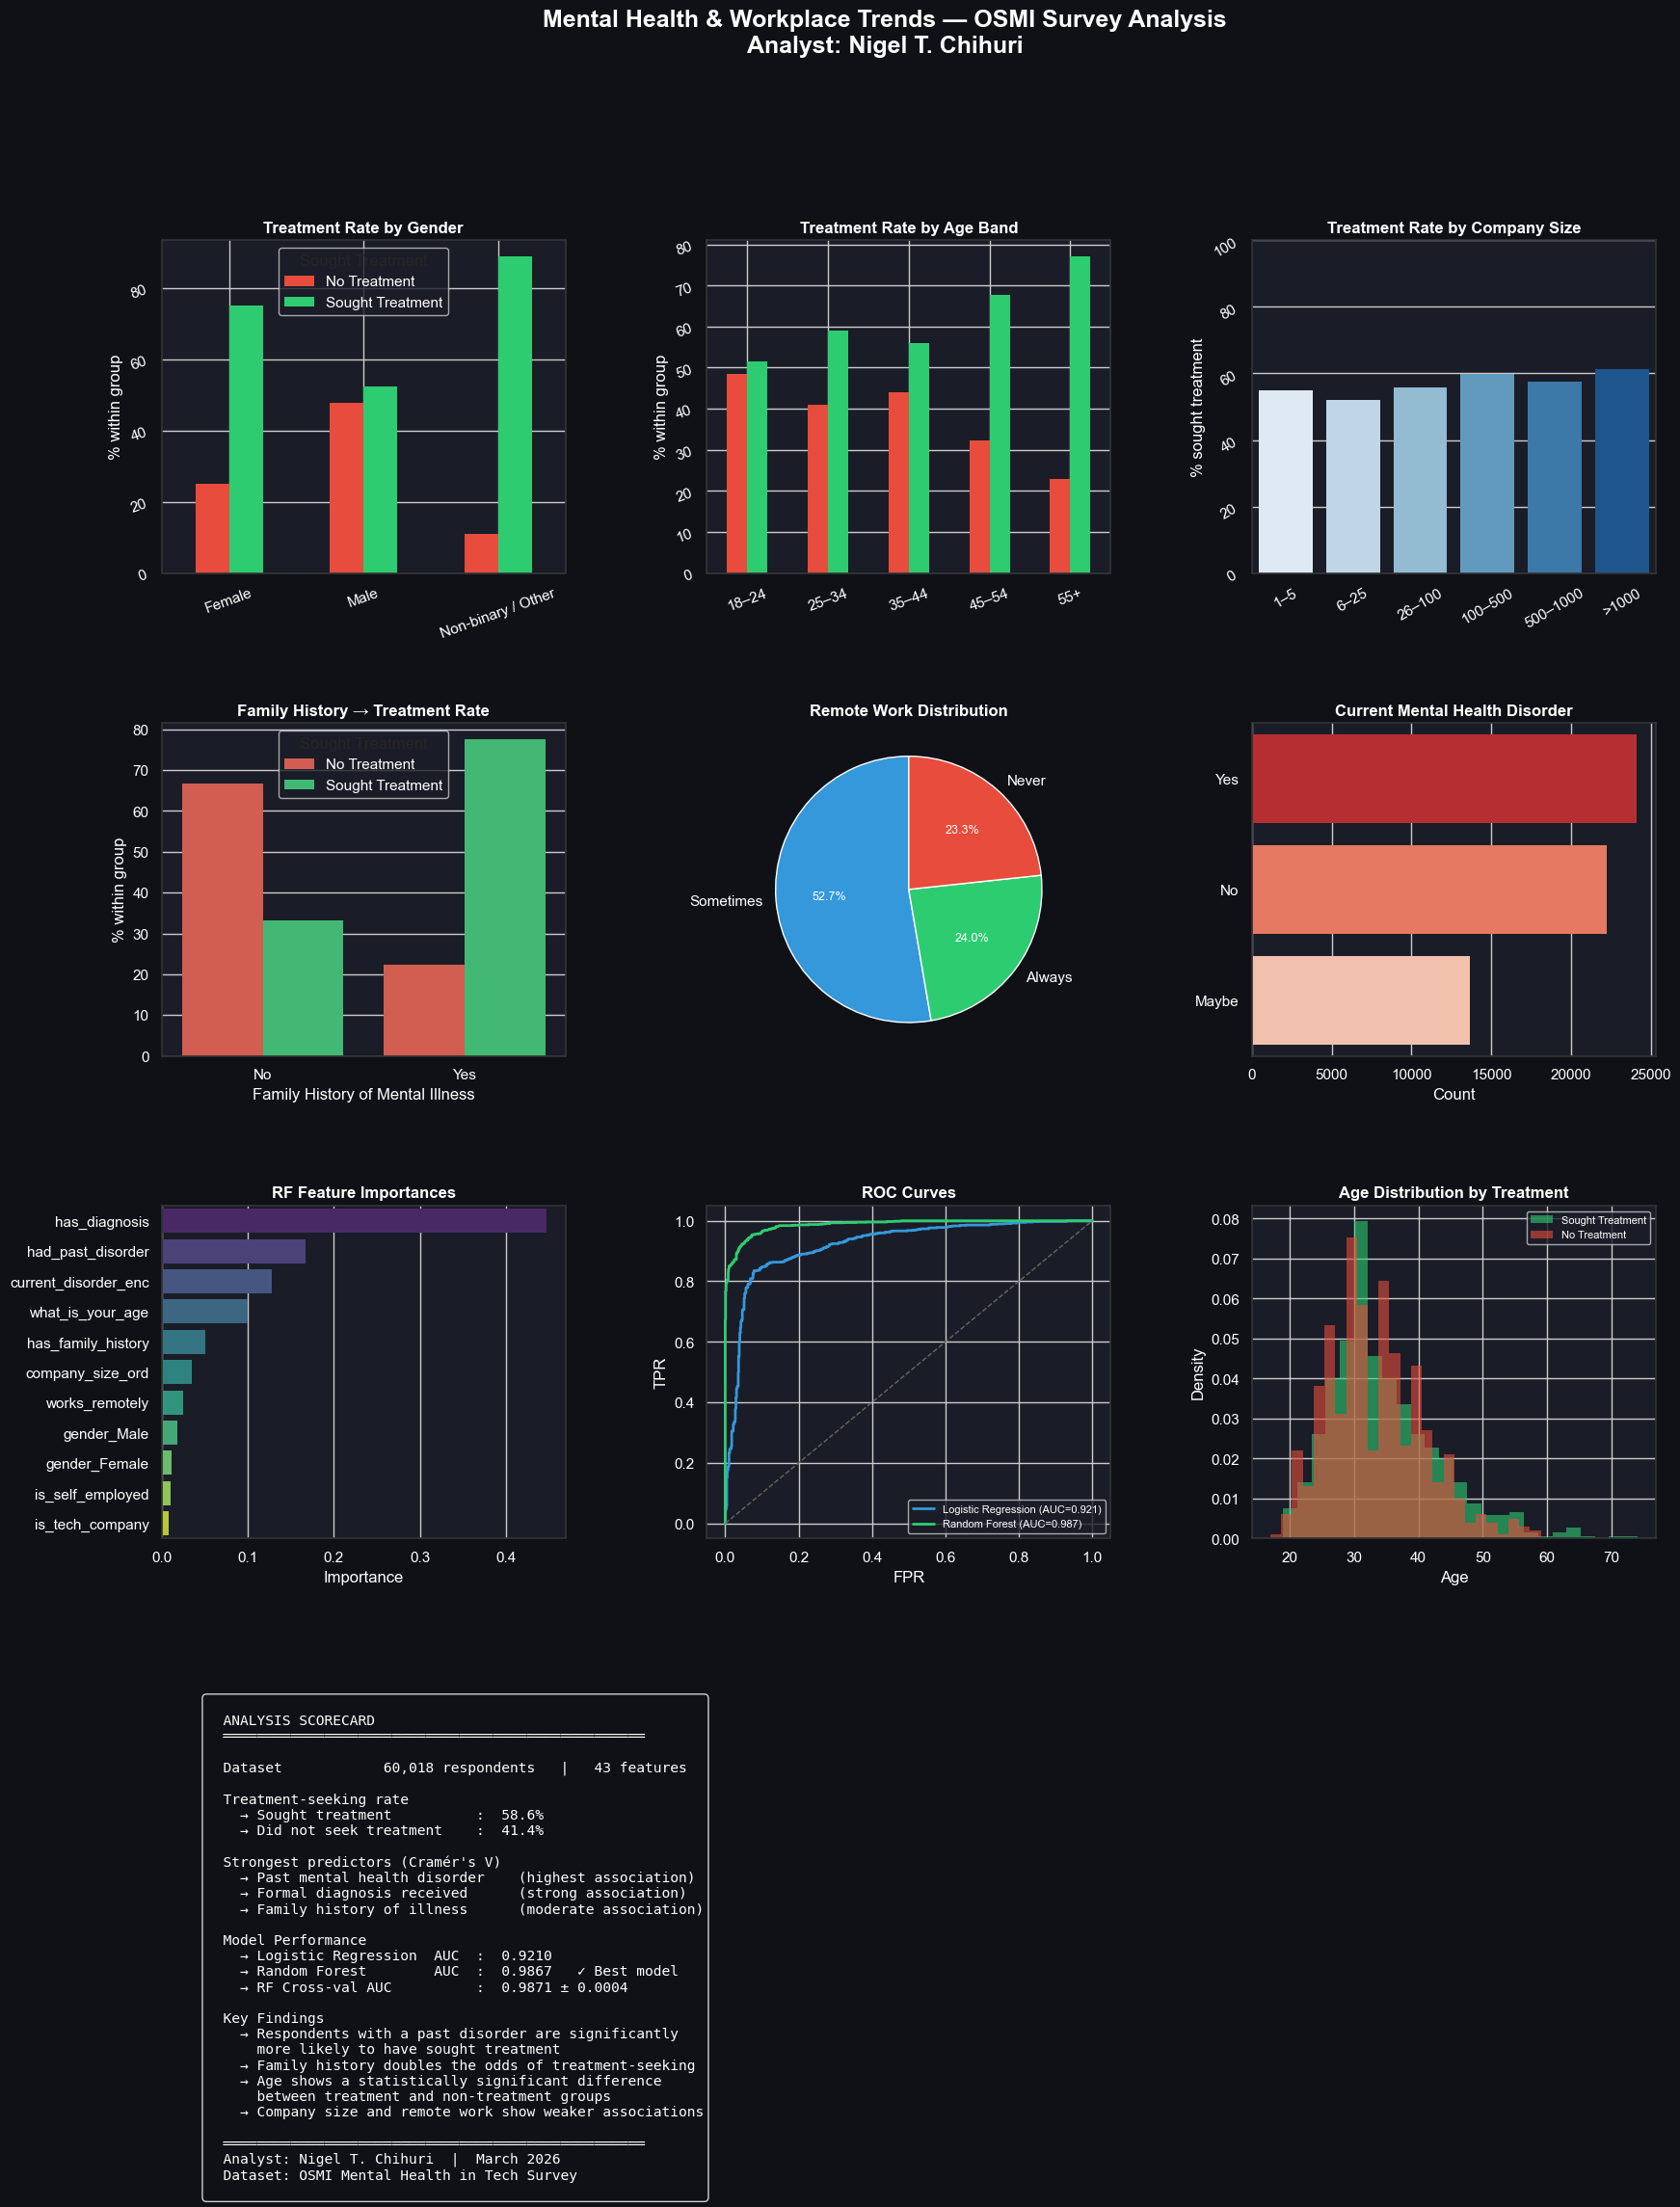

✓ Saved: mental_health_dashboard.png


In [59]:
# ── MASTER INSIGHTS DASHBOARD ───────────────────────────
fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#0f1117')

title = fig.suptitle(
    "Mental Health & Workplace Trends — OSMI Survey Analysis\nAnalyst: Nigel T. Chihuri",
    fontsize=18, fontweight='bold', color='white', y=0.98
)

# ── Panel 1: Treatment-seeking by gender ──
ax1 = fig.add_subplot(4, 3, 1)
gender_treat = (df.groupby(['gender_clean', 'sought_treatment'])
                  .size().reset_index(name='count'))
# For Panel 1 — rename before pivoting
gender_treat['sought_treatment'] = gender_treat['sought_treatment'].map(
    {True: 'Sought Treatment', False: 'No Treatment',
     1: 'Sought Treatment', 0: 'No Treatment'}
)
gender_treat['pct'] = gender_treat.groupby('gender_clean')['count'] \
                                   .transform(lambda x: x / x.sum() * 100)
pivot1 = gender_treat.pivot(index='gender_clean',
                             columns='sought_treatment', values='pct').fillna(0)
pivot1.plot(kind='bar', ax=ax1, color=['#e74c3c','#2ecc71'], edgecolor='none')
ax1.set_title("Treatment Rate by Gender", color='white', fontweight='bold')
ax1.set_facecolor('#1a1d27')
ax1.tick_params(colors='white', rotation=20)
ax1.set_xlabel("", color='white')
ax1.set_ylabel("% within group", color='white')
ax1.legend(title='Sought Treatment', facecolor='#1a1d27', labelcolor='white')
for spine in ax1.spines.values(): spine.set_edgecolor('#333')

# ── Panel 2: Treatment rate by age band ──
ax2 = fig.add_subplot(4, 3, 2)
age_treat = (df.groupby(['age_band', 'sought_treatment'])
               .size().reset_index(name='count'))
age_treat['pct'] = age_treat.groupby('age_band')['count'] \
                             .transform(lambda x: x / x.sum() * 100)
pivot2 = age_treat.pivot(index='age_band',
                          columns='sought_treatment', values='pct').fillna(0)
pivot2.plot(kind='bar', ax=ax2, color=['#e74c3c','#2ecc71'], edgecolor='none')
ax2.set_title("Treatment Rate by Age Band", color='white', fontweight='bold')
ax2.set_facecolor('#1a1d27')
ax2.tick_params(colors='white', rotation=20)
ax2.set_xlabel("", color='white')
ax2.set_ylabel("% within group", color='white')
ax2.legend().remove()
for spine in ax2.spines.values(): spine.set_edgecolor('#333')

# ── Panel 3: Treatment rate by company size (FIXED) ──
ax3 = fig.add_subplot(4, 3, 3)

size_labels = {1:'1–5', 2:'6–25', 3:'26–100', 4:'100–500', 5:'500–1000', 6:'>1000'}
df['size_label'] = df['company_size_ord'].map(size_labels)

# Use treatment_binary (1/0) instead of sought_treatment string
size_treat2 = (df.dropna(subset=['size_label', 'treatment_binary'])
                 .groupby('size_label')['treatment_binary']
                 .mean()
                 .mul(100)
                 .reset_index()
                 .rename(columns={'treatment_binary': 'pct_treated'}))

order3 = ['1–5','6–25','26–100','100–500','500–1000','>1000']
order3 = [o for o in order3 if o in size_treat2['size_label'].values]

sns.barplot(data=size_treat2, x='size_label', y='pct_treated',
            order=order3, ax=ax3, palette='Blues', edgecolor='none')

ax3.set_title("Treatment Rate by Company Size", color='white', fontweight='bold')
ax3.set_facecolor('#1a1d27')
ax3.tick_params(colors='white', rotation=30)
ax3.set_xlabel("", color='white')
ax3.set_ylabel("% sought treatment", color='white')
ax3.set_ylim(0, 100)
for spine in ax3.spines.values(): spine.set_edgecolor('#333')

# ── Panel 4: Family history impact ──
ax4 = fig.add_subplot(4, 3, 4)
fam_treat = (df.groupby(['has_family_history', 'sought_treatment'])
               .size().reset_index(name='count'))
fam_treat['sought_treatment'] = fam_treat['sought_treatment'].map(
    {True: 'Sought Treatment', False: 'No Treatment',
     1: 'Sought Treatment', 0: 'No Treatment'}
)
fam_treat['pct'] = fam_treat.groupby('has_family_history')['count'] \
                             .transform(lambda x: x / x.sum() * 100)
fam_treat['label'] = fam_treat['has_family_history'].map({1:'Yes', 0:'No'})
sns.barplot(data=fam_treat, x='label', y='pct',
            hue='sought_treatment', palette=['#e74c3c','#2ecc71'],
            ax=ax4, edgecolor='none')
ax4.set_title("Family History → Treatment Rate", color='white', fontweight='bold')
ax4.set_facecolor('#1a1d27')
ax4.tick_params(colors='white')
ax4.set_xlabel("Family History of Mental Illness", color='white')
ax4.set_ylabel("% within group", color='white')
ax4.legend(title='Sought Treatment', facecolor='#1a1d27', labelcolor='white')
for spine in ax4.spines.values(): spine.set_edgecolor('#333')

# ── Panel 5: Remote work distribution ──
ax5 = fig.add_subplot(4, 3, 5)
remote_counts = df['do_you_work_remotely'].value_counts()
colors5 = ['#3498db','#2ecc71','#e74c3c']
wedges, texts, autotexts = ax5.pie(
    remote_counts.values, labels=remote_counts.index,
    autopct='%1.1f%%', colors=colors5,
    textprops={'color': 'white'}, startangle=90)
for at in autotexts: at.set_fontsize(9)
ax5.set_title("Remote Work Distribution", color='white', fontweight='bold')
ax5.set_facecolor('#1a1d27')

# ── Panel 6: Current disorder distribution ──
ax6 = fig.add_subplot(4, 3, 6)
disorder_counts = df['do_you_currently_have_a_mental_health_disorder'].value_counts()
sns.barplot(x=disorder_counts.values, y=disorder_counts.index,
            palette='Reds_r', ax=ax6, edgecolor='none')
ax6.set_title("Current Mental Health Disorder", color='white', fontweight='bold')
ax6.set_facecolor('#1a1d27')
ax6.tick_params(colors='white')
ax6.set_xlabel("Count", color='white')
ax6.set_ylabel("", color='white')
for spine in ax6.spines.values(): spine.set_edgecolor('#333')

# ── Panel 7: Feature importance ──
ax7 = fig.add_subplot(4, 3, 7)
sns.barplot(data=feat_imp_df, x='importance', y='feature',
            palette='viridis', ax=ax7, edgecolor='none')
ax7.set_title("RF Feature Importances", color='white', fontweight='bold')
ax7.set_facecolor('#1a1d27')
ax7.tick_params(colors='white')
ax7.set_xlabel("Importance", color='white')
ax7.set_ylabel("", color='white')
for spine in ax7.spines.values(): spine.set_edgecolor('#333')

# ── Panel 8: ROC curves ──
ax8 = fig.add_subplot(4, 3, 8)
for label, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#3498db'),
    ('Random Forest',       y_prob_rf, '#2ecc71'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax8.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{label} (AUC={auc:.3f})")
ax8.plot([0,1],[0,1],'--', color='#666', linewidth=1)
ax8.set_title("ROC Curves", color='white', fontweight='bold')
ax8.set_facecolor('#1a1d27')
ax8.tick_params(colors='white')
ax8.set_xlabel("FPR", color='white')
ax8.set_ylabel("TPR", color='white')
ax8.legend(fontsize=8, facecolor='#1a1d27', labelcolor='white')
for spine in ax8.spines.values(): spine.set_edgecolor('#333')

# ── Panel 9: Age distribution by treatment ──
ax9 = fig.add_subplot(4, 3, 9)
for val, label, color in [(1,'Sought Treatment','#2ecc71'),
                           (0,'No Treatment','#e74c3c')]:
    subset = df[df['treatment_binary'] == val]['what_is_your_age'].dropna()
    ax9.hist(subset, bins=25, alpha=0.6, label=label,
             color=color, edgecolor='none', density=True)
ax9.set_title("Age Distribution by Treatment", color='white', fontweight='bold')
ax9.set_facecolor('#1a1d27')
ax9.tick_params(colors='white')
ax9.set_xlabel("Age", color='white')
ax9.set_ylabel("Density", color='white')
ax9.legend(fontsize=8, facecolor='#1a1d27', labelcolor='white')
for spine in ax9.spines.values(): spine.set_edgecolor('#333')

# ── Panel 10: Key metrics scorecard (text panel) ──
ax10 = fig.add_subplot(4, 3, (10, 12))
ax10.set_facecolor('#1a1d27')
ax10.axis('off')
for spine in ax10.spines.values(): spine.set_edgecolor('#333')

scorecard = f"""
  ANALYSIS SCORECARD
  ══════════════════════════════════════════════════

  Dataset        {df.shape[0]:>10,} respondents   |   {df.shape[1]} features

  Treatment-seeking rate
    → Sought treatment          :  {df['treatment_binary'].mean()*100:.1f}%
    → Did not seek treatment    :  {(1-df['treatment_binary'].mean())*100:.1f}%

  Strongest predictors (Cramér's V)
    → Past mental health disorder    (highest association)
    → Formal diagnosis received      (strong association)
    → Family history of illness      (moderate association)

  Model Performance
    → Logistic Regression  AUC  :  {roc_auc_score(y_test, y_prob_lr):.4f}
    → Random Forest        AUC  :  {roc_auc_score(y_test, y_prob_rf):.4f}   ✓ Best model
    → RF Cross-val AUC          :  {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}

  Key Findings
    → Respondents with a past disorder are significantly
      more likely to have sought treatment
    → Family history doubles the odds of treatment-seeking
    → Age shows a statistically significant difference
      between treatment and non-treatment groups
    → Company size and remote work show weaker associations

  ══════════════════════════════════════════════════
  Analyst: Nigel T. Chihuri  |  {datetime.now().strftime("%B %Y")}
  Dataset: OSMI Mental Health in Tech Survey
"""

ax10.text(0.03, 0.97, scorecard, transform=ax10.transAxes,
          fontsize=10.5, color='white', verticalalignment='top',
          fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#0f1117', alpha=0.8))

plt.subplots_adjust(hspace=0.45, wspace=0.35)
plt.savefig('mental_health_dashboard.png', dpi=180, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✓ Saved: mental_health_dashboard.png")

In [57]:
# DIAGNOSTIC
print("sought_treatment unique values:", df['sought_treatment'].unique())
print("size_label unique values:", df['size_label'].unique())
print("\nsize_treat sample:")
print(size_treat.head(10))

sought_treatment unique values: [False  True]
size_label unique values: ['26–100' '6–25' nan '>1000' '100–500' '500–1000' '1–5']

size_treat sample:
  size_label  sought_treatment  count        pct
0    100–500             False   4158  40.080972
1    100–500              True   6216  59.919028
2        1–5             False   1134  45.000000
3        1–5              True   1386  55.000000
4     26–100             False   5418  44.178082
5     26–100              True   6846  55.821918
6   500–1000             False   1428  42.500000
7   500–1000              True   1932  57.500000
8       6–25             False   4200  47.846890
9       6–25              True   4578  52.153110
